In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
from yellowbrick.cluster import KElbowVisualizer
import matplotlib.pyplot as plt
import pandas as pd 
import seaborn as sns
from sklearn.cluster import KMeans
from sksurv.base import SurvivalAnalysisMixin as s
from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_val_score
from sksurv.preprocessing import encode_categorical
 
from sksurv.functions import StepFunction
from sksurv.linear_model import CoxPHSurvivalAnalysis, CoxnetSurvivalAnalysis
from sksurv.ensemble import (ComponentwiseGradientBoostingSurvivalAnalysis, 
                            RandomSurvivalForest, 
                            ExtraSurvivalTrees, 
                            GradientBoostingSurvivalAnalysis, 
                            ExtraSurvivalTrees)
from sksurv.meta import EnsembleSelection, EnsembleSelectionRegressor
from sksurv.metrics import integrated_brier_score
from matplotlib.colors import ListedColormap
from mlxtend.evaluate import paired_ttest_5x2cv
from mlxtend.evaluate import combined_ftest_5x2cv
from lifelines import KaplanMeierFitter
from scipy.cluster import hierarchy
from lifelines.statistics import logrank_test, multivariate_logrank_test, pairwise_logrank_test
from sklearn import preprocessing
from sklearn.model_selection import StratifiedKFold, KFold
from lifelines.plotting import add_at_risk_counts
import scipy.stats
import sklearn
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import optuna
from sklearn.model_selection import cross_val_score
from sksurv.metrics import integrated_brier_score
from lifelines import CoxPHFitter
from lifelines.statistics import proportional_hazard_test
import scipy.stats as stats
from statsmodels.stats.outliers_influence import variance_inflation_factor 
 
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = 'all'
from sklearn.preprocessing import RobustScaler

In [2]:
# OUS: Train data
OUS_D1 = pd.read_csv('OUS_D1.csv')
OUS_D2 = pd.read_csv('OUS_D2.csv')
OUS_D3 = pd.read_csv('OUS_D3.csv')
OUS_DFS_target = pd.read_csv('OUS_DFS_target.csv')
OUS_OS_target = pd.read_csv('OUS_OS_target.csv')
response_OUS = pd.read_csv('response_ous.csv', sep=';')

# MAASTRO: Test data 
MAASTRO_D1 = pd.read_csv('MAASTRO_D1.csv')
MAASTRO_D2 = pd.read_csv('MAASTRO_D2.csv')
MAASTRO_D3 = pd.read_csv('MAASTRO_D3.csv')
MAASTRO_DFS_target = pd.read_csv('MAASTRO_DFS_target.csv')
MAASTRO_OS_target = pd.read_csv('MAASTRO_OS_target.csv')
response_MAASTRO = pd.read_csv('maastro_response_full.csv', sep=',')

In [3]:
# Need to choose patient_id from OUS_D3 in response_OUS
data = list(OUS_D3['patient_id'])
mask = response_OUS['patient_id'].isin(data)
response_OUS = response_OUS[mask] 

# Merge OUS_D3 with response_OUS
clinical_train = pd.merge(OUS_D3, response_OUS, on='patient_id', how='inner')
clinical_train = clinical_train.loc[:, ~clinical_train.columns.isin(['DFS', 'event_DFS', 'LRC', 'event_LRC'])]

In [4]:
# Drop patient_id column
clinical_train = clinical_train.drop('patient_id', axis=1)

In [5]:
# Check null values in D2 
clinical_train.isnull().sum().sum()

0

## Test dataset: MAASTRO 

In [6]:
(MAASTRO_D3['patient_id'] == MAASTRO_OS_target['patient_id']).sum()

99

In [7]:
# Rename the column name of response_MAASTRO 
response_MAASTRO.rename(columns = {'Index' : 'patient_id'}, inplace = True)

In [8]:
# need to choose patient_id from MAASTRO_D3 in response_MAASTRO
data = list(MAASTRO_D3['patient_id'])
mask = response_MAASTRO['patient_id'].isin(data)
response_MAASTRO = response_MAASTRO[mask] 
response_MAASTRO

,patient_id,OS,OS_event,LRC,LRC_event,DFS,DFS_event
0,1,62.43,0.0,62.43,0.0,62.43,0.0
1,2,60.00,0.0,60.00,0.0,60.00,0.0
2,3,44.43,1.0,8.83,1.0,8.83,1.0
3,4,37.20,1.0,19.37,0.0,19.73,1.0
5,6,59.23,0.0,59.23,0.0,59.23,0.0
...,...,...,...,...,...,...,...
109,110,19.00,1.0,13.27,1.0,13.27,1.0
110,111,85.87,1.0,82.83,0.0,85.87,1.0
111,112,42.87,0.0,42.87,0.0,42.87,0.0
112,113,58.93,0.0,58.93,0.0,58.93,0.0


In [9]:
# Merge MAASTRO_D3 with response_MAASTRO
clinical_test = pd.merge(MAASTRO_D3, response_MAASTRO, on='patient_id', how='inner')
clinical_test = clinical_test.loc[:, ~clinical_test.columns.isin(['DFS', 'DFS_event', 'LRC', 'LRC_event'])]
clinical_test

,patient_id,age,female,cavum_oris,oropharynx,hypopharynx,larynx,histgrade_high,hpv_related,charlson,...,LBP_021_PET,LBP_030_PET,LBP_102_PET,LBP_111_PET,LBP_120_PET,LBP_201_PET,LBP_210_PET,LBP_300_PET,OS,OS_event
0,1,55,0,0,1,0,0,1,1,1,...,0.028808,0.837387,0.000026,0.001705,0.122209,0.000026,0.008291,0.000341,62.43,0.0
1,2,55,0,0,1,0,0,0,0,0,...,0.049615,0.806842,0.000167,0.002958,0.128976,0.000167,0.008148,0.000335,60.00,0.0
2,3,55,0,0,1,0,0,0,0,1,...,0.019514,0.830272,0.000057,0.001831,0.137282,0.000000,0.008641,0.000229,44.43,1.0
3,4,61,1,0,0,0,1,1,0,1,...,0.047155,0.760949,0.000000,0.003597,0.171595,0.000080,0.013187,0.000240,37.20,1.0
4,6,70,0,0,1,0,0,1,1,1,...,0.033990,0.824865,0.000000,0.002116,0.128134,0.000035,0.009379,0.000529,59.23,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
94,110,66,1,0,0,0,1,0,0,0,...,0.017489,0.834590,0.000000,0.001321,0.137194,0.000078,0.008706,0.000078,19.00,1.0
95,111,63,0,0,0,0,1,0,0,1,...,0.029979,0.821431,0.000000,0.000543,0.137620,0.000054,0.008907,0.000489,85.87,1.0
96,112,63,0,0,1,0,0,1,1,1,...,0.017354,0.859957,0.000000,0.000988,0.115099,0.000028,0.005700,0.000141,42.87,0.0
97,113,54,0,0,1,0,0,1,1,0,...,0.025399,0.847908,0.000000,0.001487,0.117654,0.000000,0.005759,0.000038,58.93,0.0


In [10]:
# Drop patient_id column
clinical_test = clinical_test.drop('patient_id', axis=1)

In [11]:
# Some rows have null values in OS, OS_event -> Remove those rows
clinical_test[clinical_test.isnull().any(axis=1)]
clinical_test = clinical_test.dropna(how='any',axis=0) 

,age,female,cavum_oris,oropharynx,hypopharynx,larynx,histgrade_high,hpv_related,charlson,pack_years,...,LBP_021_PET,LBP_030_PET,LBP_102_PET,LBP_111_PET,LBP_120_PET,LBP_201_PET,LBP_210_PET,LBP_300_PET,OS,OS_event


In [12]:
# X
X = clinical_train.loc[:, ~clinical_train.columns.isin(['OS', 'event_OS'])]

# y 
y = clinical_train.loc[:, ['OS', 'event_OS']]

In [13]:
# Set lower, upper time point and times for IBS calculation later 
lower, upper = np.percentile(y['OS'], [10, 90])
times = np.arange(lower, upper)

# y into array 
lists = [] 
for i, j in zip(y['event_OS'], y['OS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [14]:
# Shape
print('X_train: ', X.shape)
print('y_train: ', y.shape)

X_train:  (139, 388)
y_train:  (139,)


In [15]:
clinical_test.rename(columns = {'OS_event' : 'event_OS'}, inplace = True)

In [16]:
# X
X_MAASTRO = clinical_test.loc[:, ~clinical_test.columns.isin(['OS', 'event_OS'])]

# y y_MAASTRO
y_MAASTRO = clinical_test.loc[:, ['OS', 'event_OS']]
lower, upper = np.percentile(y_MAASTRO['OS'], [10, 90])
times = np.arange(lower, upper)

# y into array 
lists = [] 
for i, j in zip(y_MAASTRO['event_OS'], y_MAASTRO['OS']): 
    lists.append((i, j))

y_MAASTRO = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

clinical_test.shape

(99, 390)

# Standardization for Clustering

In [17]:
original_X = X.copy()

In [18]:
# Standardize the data 
## Save the column and index 
X_columns = X.columns 
X_index = X.index

## Standardize the data but not the categorical columns
categorical_columns = ['female', 
                        'cavum_oris',
                        'oropharynx',
                        'hypopharynx',
                        'larynx',
                        'histgrade_high',
                        'hpv_related',
                        'charlson',
                        'uicc8_III-IV']
### Separate the categorical and non-categorical columns
X_categorical = X[categorical_columns]
X_numeric = X.drop(categorical_columns, axis=1)
X_numeric_columns = X_numeric.columns
X_numeric_index = X_numeric.index

### Standardize non-categorical and then concat with the categorical using the min max scaling
scaler = RobustScaler()  
X_numeric_std = scaler.fit_transform(X_numeric)
X_numeric_std = pd.DataFrame(X_numeric_std, columns=X_numeric_columns, index=X_numeric_index)
X_std = pd.concat([X_categorical, X_numeric_std], axis=1)

## Sort the order of the columns as it was in the clinical train 
X_std = X_std[original_X.columns]

# Clustering

KElbowVisualizer(ax=<AxesSubplot:>, estimator=KMeans(n_clusters=9), k=(2, 10))

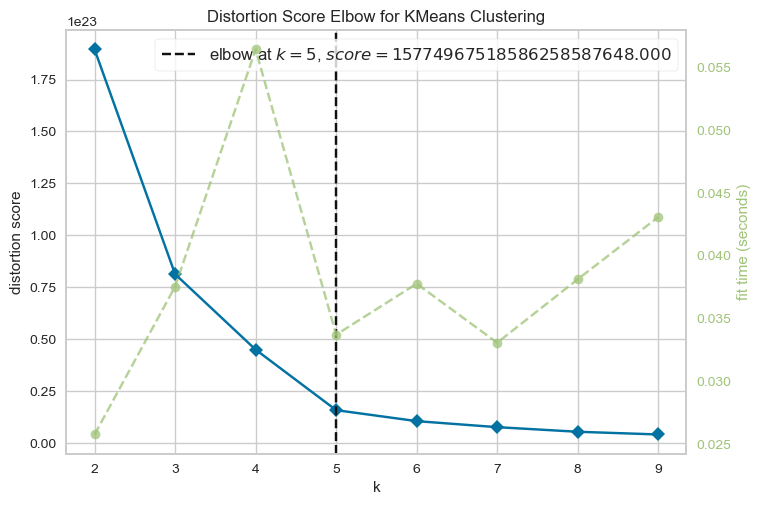

<AxesSubplot:title={'center':'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [19]:
# Decide how many clusters to form 
X_transposed = X_std.T

kmeans = KMeans()
ssd = []
K = range(2, 10)

for k in K:
    kmeans = KMeans(n_clusters=k).fit(X_transposed)
    ssd.append(kmeans.inertia_)

kmeans = KMeans()
visu = KElbowVisualizer(kmeans, k=(2, 10))
visu.fit(clinical_train)
visu.show()

### Using the highest feature importance

In [20]:
num_clusters = 5  
kmeans = KMeans(n_clusters=num_clusters)
kmeans.fit(X_std.T)
cluster_labels = kmeans.labels_

selected_features = [] 
for i in range(5):
    coxph = CoxPHFitter(penalizer=0.00001)
    X_cluster = X_std[X_std.columns[cluster_labels==i]]
    X_cluster = pd.concat([X_cluster, clinical_train[['OS', 'event_OS']]], axis=1)
    coxph.fit(X_cluster, duration_col='OS', event_col='event_OS')

    # Get coefficients and associated feature names
    coefficients = coxph.summary['coef']
    feature_names = coxph.summary.index

    # Create a DataFrame to store coefficients and feature names
    coefficients_df = pd.DataFrame({'Feature': feature_names, 'Coefficient': coefficients})

    # Take absolute values of coefficients
    coefficients_df['Abs_Coefficient'] = coefficients_df['Coefficient'].abs()

    # Sort coefficients by absolute value to identify important features
    sorted_coefficients_df = coefficients_df.sort_values(by='Abs_Coefficient', ascending=False)

    # Display the column with the highest feature importance and its coefficient value
    max_coefficient_feature = sorted_coefficients_df.loc[sorted_coefficients_df['Abs_Coefficient'].idxmax()]
    print(f"Cluster {i}: Most important feature: {max_coefficient_feature['Feature']}, Coefficient: {max_coefficient_feature['Coefficient']}")
    selected_features.append(max_coefficient_feature['Feature'])
  

KMeans(n_clusters=5)

<lifelines.CoxPHFitter: fitted with 139 total observations, 82 right-censored observations>

Cluster 0: Most important feature: glcm_Correlation_d_1_CT_c16, Coefficient: 2.0608148119708916


<lifelines.CoxPHFitter: fitted with 139 total observations, 82 right-censored observations>

Cluster 1: Most important feature: glszm_LargeAreaLowGrayLevelEmphasis_PET_c04, Coefficient: 0.0019789270488082635


...

Cluster 2: Most important feature: glszm_LargeAreaEmphasis_PET_c04, Coefficient: 0.08115498962564245


<lifelines.CoxPHFitter: fitted with 139 total observations, 82 right-censored observations>

Cluster 3: Most important feature: glrlm_ShortRunLowGrayLevelEmphasis_CT_b20, Coefficient: -0.5677274769020084


<lifelines.CoxPHFitter: fitted with 139 total observations, 82 right-censored observations>

Cluster 4: Most important feature: gldm_DependenceNonUniformity_d_1_PET_c04, Coefficient: -0.2932143723470227


In [21]:
selected_features

['glcm_Correlation_d_1_CT_c16',
 'glszm_LargeAreaLowGrayLevelEmphasis_PET_c04',
 'glszm_LargeAreaEmphasis_PET_c04',
 'glrlm_ShortRunLowGrayLevelEmphasis_CT_b20',
 'gldm_DependenceNonUniformity_d_1_PET_c04']

In [22]:
# Selecting features in the DataFrame
X_fs_fi = X[selected_features]
X_new = X_fs_fi.copy()

X_MAASTRO_fs_fi = X_MAASTRO[selected_features]
MAASTRO_new = X_MAASTRO_fs_fi.copy()

# Standardization

In [23]:
# Standardize X_new, the new data with the selected features only 
categorical_columns = ['female', 
                        'cavum_oris',
                        'oropharynx',
                        'hypopharynx',
                        'larynx',
                        'histgrade_high',
                        'hpv_related',
                        'charlson',
                        'uicc8_III-IV']

# Set the columns_to_drop which are categorical 
columns_to_drop = [col for col in X_new.columns if col in categorical_columns]

# Drop the columns if they exist in the DataFrame and save the numeric part in X_new_numeric
X_new_categoric = X_new[columns_to_drop]
X_new_numeric = X_new.drop(columns=columns_to_drop, inplace=False)

# Do the standardization for the numeric part 
scaler = RobustScaler() 
X_new_numeric_columns = X_new_numeric.columns
X_new_numeric_index = X_new_numeric.index 
X_new_numeric_std = scaler.fit_transform(X_new_numeric)
X_new_numeric_std = pd.DataFrame(X_new_numeric_std,
                                 columns=X_new_numeric_columns, 
                                 index=X_new_numeric_index)
X_new_std = pd.concat([X_new_numeric_std, X_new_categoric], axis=1)

# Change the order of the X_new_std 
X_new_std = X_new_std[X_new.columns]

In [24]:
# Standardize X_MAASTRO 
# Set the columns_to_drop which are categorical 
columns_to_drop = [col for col in MAASTRO_new.columns if col in categorical_columns]

# Drop the columns if they exist in the DataFrame and save the numeric part in X_new_numeric
MAASTRO_new_categoric = MAASTRO_new[columns_to_drop]
MAASTRO_new_numeric = MAASTRO_new.drop(columns=columns_to_drop, inplace=False)

# Do the standardization for the numeric part 
MAASTRO_new_numeric_columns = MAASTRO_new_numeric.columns
MAASTRO_new_numeric_columns = MAASTRO_new_numeric.columns
MAASTRO_new_numeric_index = MAASTRO_new_numeric.index 
MAASTRO_new_numeric_std = scaler.transform(MAASTRO_new_numeric)
MAASTRO_new_numeric_std = pd.DataFrame(MAASTRO_new_numeric_std,
                                 columns=MAASTRO_new_numeric_columns, 
                                 index=MAASTRO_new_numeric_index)
MAASTRO_new_std = pd.concat([MAASTRO_new_numeric_std, MAASTRO_new_categoric], axis=1)

# Change the order of the X_new_std 
MAASTRO_new_std = MAASTRO_new_std[MAASTRO_new.columns]

In [25]:
X_new

,glcm_Correlation_d_1_CT_c16,glszm_LargeAreaLowGrayLevelEmphasis_PET_c04,glszm_LargeAreaEmphasis_PET_c04,glrlm_ShortRunLowGrayLevelEmphasis_CT_b20,gldm_DependenceNonUniformity_d_1_PET_c04
0,0.712490,879096.343994,3.392207e+06,0.000536,1132.849143
1,0.523607,26566.901706,9.996325e+04,0.001324,177.023053
2,0.660634,647295.586841,4.566579e+06,0.000455,1888.886026
3,0.541994,40145.962374,1.798434e+05,0.000847,211.940366
4,0.441477,10927.978256,1.231554e+05,0.001143,346.285373
...,...,...,...,...,...
134,0.680265,215024.891557,7.130061e+05,0.001070,517.454513
135,0.724195,338158.975184,4.579243e+06,0.000553,1592.627288
136,0.607412,974304.249507,2.589594e+06,0.000739,1021.684898
137,0.526798,199030.525466,1.972581e+06,0.000770,1295.643252


In [26]:
X_new_std

,glcm_Correlation_d_1_CT_c16,glszm_LargeAreaLowGrayLevelEmphasis_PET_c04,glszm_LargeAreaEmphasis_PET_c04,glrlm_ShortRunLowGrayLevelEmphasis_CT_b20,gldm_DependenceNonUniformity_d_1_PET_c04
0,0.486981,0.627985,0.345099,-0.230645,0.123942
1,-0.817056,-0.249270,-0.349687,0.773474,-0.517944
2,0.128970,0.389462,0.592935,-0.333883,0.631659
3,-0.690116,-0.235297,-0.332829,0.165736,-0.494495
4,-1.384077,-0.265362,-0.344792,0.543393,-0.404276
...,...,...,...,...,...
134,0.264499,-0.055346,-0.220312,0.450506,-0.289327
135,0.567791,0.071360,0.595608,-0.209520,0.432706
136,-0.238476,0.725955,0.175718,0.027569,0.049289
137,-0.795025,-0.071804,0.045505,0.068003,0.233267


In [27]:
MAASTRO_new

,glcm_Correlation_d_1_CT_c16,glszm_LargeAreaLowGrayLevelEmphasis_PET_c04,glszm_LargeAreaEmphasis_PET_c04,glrlm_ShortRunLowGrayLevelEmphasis_CT_b20,gldm_DependenceNonUniformity_d_1_PET_c04
0,0.587378,1.125054e+06,5.846775e+06,0.000574,2486.104657
1,0.777112,1.948450e+06,3.873610e+06,0.002657,1223.288872
2,0.734733,1.403912e+06,3.214991e+06,0.000617,1128.604578
3,0.817507,4.555744e+05,1.459965e+06,0.005186,758.871164
4,0.633481,8.660429e+05,4.406102e+06,0.000393,1924.271323
...,...,...,...,...,...
94,0.643053,9.500595e+05,1.483641e+06,0.000635,803.301749
95,0.836867,3.718008e+06,5.977704e+06,0.003568,1121.977787
96,0.614573,2.726200e+06,1.178081e+07,0.000344,2157.170772
97,0.719432,2.138315e+06,6.169522e+06,0.000467,1866.857748


In [28]:
MAASTRO_new_std

,glcm_Correlation_d_1_CT_c16,glszm_LargeAreaLowGrayLevelEmphasis_PET_c04,glszm_LargeAreaEmphasis_PET_c04,glrlm_ShortRunLowGrayLevelEmphasis_CT_b20,gldm_DependenceNonUniformity_d_1_PET_c04
0,-0.376785,0.881077,0.863105,-0.182714,1.032722
1,0.933124,1.728353,0.446693,2.473143,0.184677
2,0.640542,1.168022,0.307700,-0.127674,0.121092
3,1.212005,0.192180,-0.062676,5.697766,-0.127203
4,-0.058496,0.614553,0.559069,-0.413366,0.655422
...,...,...,...,...,...
94,0.007587,0.701007,-0.057679,-0.104615,-0.097366
95,1.345670,3.549233,0.890735,3.635137,0.116641
96,-0.189032,2.528660,2.115407,-0.475501,0.811826
97,0.534907,1.923725,0.931216,-0.318530,0.616866


# Modelling 

### 1. CoxPHSurvivalAnalysis

#### Train

In [29]:
# Setting the y format for skf below  
y = clinical_train[['OS', 'event_OS']]

# Running to optuna for hyperparameter tuning 
def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Create and fit survival model 
        model = model_class()
        
        scores = [] 

        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_OS'], y_train_df['OS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_OS'], y_test_df['OS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            # Robust Standardization
            excluded_columns = ['female', 
                                'cavum_oris',
                                'oropharynx',
                                'hypopharynx',
                                'larynx',
                                'histgrade_high',
                                'hpv_related',
                                'charlson',
                                'uicc8_III-IV'
                               ]
            excluded_columns = set(excluded_columns).intersection(X.columns)

            scaler = RobustScaler() 
            X_train_included = X_train.drop(excluded_columns, axis=1)
            X_test_included = X_test.drop(excluded_columns, axis=1)
                        
            if not X_train_included.empty and not X_test_included.empty:
                X_train_included_std = scaler.fit_transform(X_train_included)
                X_test_included_std = scaler.transform(X_test_included)
                
                # Concatenation
                X_train_std_df = pd.DataFrame(X_train_included_std, columns=X_train_included.columns, index=X_train_included.index)
                X_train_std = pd.concat([X_train_std_df, X_train[excluded_columns]], axis=1)

                X_test_std_df = pd.DataFrame(X_test_included_std, columns=X_test_included.columns, index=X_test_included.index)
                X_test_std = pd.concat([X_test_std_df, X_test[excluded_columns]], axis=1)
            
            else: 
                X_train_std = X_train
                X_test_std = X_test 
            
            model.fit(X_train_std, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test_std, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                cox_surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test_std)])
                ibs = integrated_brier_score(y_test, y_test, cox_surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(CoxPHSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(CoxPHSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)

[I 2024-04-17 13:47:19,419] A new study created in memory with name: no-name-040782f5-8410-478b-b9a0-b12d24b97e7e


  0%|          | 0/1 [00:00<?, ?it/s]

[I 2024-04-17 13:47:19,642] A new study created in memory with name: no-name-1ce773cf-a9ff-461b-8cb3-211eed0342a6


Fold 1 C-index: 0.5151515151515151
Fold 2 C-index: 0.78125
Fold 3 C-index: 0.45588235294117646
Fold 4 C-index: 0.5864978902953587
Fold 5 C-index: 0.6244131455399061
[I 2024-04-17 13:47:19,629] Trial 0 finished with value: 0.5926389807855912 and parameters: {}. Best is trial 0 with value: 0.5926389807855912.


* Best trial for C-index: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.5926389807855912], datetime_start=datetime.datetime(2024, 4, 17, 13, 47, 19, 487717), datetime_complete=datetime.datetime(2024, 4, 17, 13, 47, 19, 629647), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for C-index: 
 0.5926389807855912


  0%|          | 0/1 [00:00<?, ?it/s]

Fold 1 IBS: 0.27403232615935585
Fold 2 IBS: 0.1851053705996257
Fold 3 IBS: 0.20756780048760695
Fold 4 IBS: 0.19474593140162103
Fold 5 IBS: 0.2037374768720667
[I 2024-04-17 13:47:19,852] Trial 0 finished with value: 0.21303778110405522 and parameters: {}. Best is trial 0 with value: 0.21303778110405522.


* Best trial for IBS: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.21303778110405522], datetime_start=datetime.datetime(2024, 4, 17, 13, 47, 19, 675905), datetime_complete=datetime.datetime(2024, 4, 17, 13, 47, 19, 852454), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for IBS: 
 0.21303778110405522


In [30]:
# Setting a dictionary to save the train results 
train_cindex = {} 
train_ibs = {} 

# Saving the values to the dictionary 
train_cindex['CoxPH'] = np.round(study_cindex.best_value, 3)
train_ibs['CoxPH'] = np.round(study_ibs.best_value, 3)

In [31]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.593
train_ibs:  0.213


#### Test

In [32]:
# y into array 
lists = [] 
for i, j in zip(y['event_OS'], y['OS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [33]:
# Test on MAASTRO 
cph = CoxPHSurvivalAnalysis()

cph.fit(X_new_std, y)

# Save C-index 
c_index = cph.score(MAASTRO_new_std, y_MAASTRO)
c_index = np.round(c_index, 3)
print('Concordance index:', c_index)

# Save IBS 
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in cph.predict_survival_function(MAASTRO_new_std)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print('IBS score:', ibs)

CoxPHSurvivalAnalysis()

Concordance index: 0.545
IBS score: 0.231


In [34]:
# Setting a dictionary to save the test results 
test_cindex = {} 
test_ibs = {} 

In [35]:
# Saving the values to the dictionary 
test_cindex['CoxPH'] = c_index
test_ibs['CoxPH'] = ibs

### 2. CoxnetSurvivalAnalysis - Ridge

#### Train

In [36]:
# Setting the y format 
y = clinical_train[['OS', 'event_OS']]

# Running to optuna for hyperparameter tuning 
def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Create and fit survival model 
        model = model_class(l1_ratio=0.0000001, 
                            fit_baseline_model=True)
        
        scores = [] 

        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_OS'], y_train_df['OS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_OS'], y_test_df['OS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            # Robust Standardization
            excluded_columns = ['female', 
                                'cavum_oris',
                                'oropharynx',
                                'hypopharynx',
                                'larynx',
                                'histgrade_high',
                                'hpv_related',
                                'charlson',
                                'uicc8_III-IV'
                               ]
            excluded_columns = set(excluded_columns).intersection(X.columns)

            scaler = RobustScaler() 
            X_train_included = X_train.drop(excluded_columns, axis=1)
            X_test_included = X_test.drop(excluded_columns, axis=1)
                        
            if not X_train_included.empty and not X_test_included.empty:
                X_train_included_std = scaler.fit_transform(X_train_included)
                X_test_included_std = scaler.transform(X_test_included)
                
                # Concatenation
                X_train_std_df = pd.DataFrame(X_train_included_std, columns=X_train_included.columns, index=X_train_included.index)
                X_train_std = pd.concat([X_train_std_df, X_train[excluded_columns]], axis=1)

                X_test_std_df = pd.DataFrame(X_test_included_std, columns=X_test_included.columns, index=X_test_included.index)
                X_test_std = pd.concat([X_test_std_df, X_test[excluded_columns]], axis=1)
            
            else: 
                X_train_std = X_train
                X_test_std = X_test 
            
            model.fit(X_train_std, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test_std, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                cox_surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test_std)])
                ibs = integrated_brier_score(y_test, y_test, cox_surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(CoxnetSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(CoxnetSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)


[I 2024-04-17 13:47:20,018] A new study created in memory with name: no-name-39e05062-fd98-472b-9942-a83e46940665


  0%|          | 0/1 [00:00<?, ?it/s]

Fold 1 C-index: 0.6277056277056277

[I 2024-04-17 13:47:20,143] A new study created in memory with name: no-name-58cfeeba-8149-4c2e-adc2-a1b2b8e7b995



Fold 2 C-index: 0.7566964285714286
Fold 3 C-index: 0.6421568627450981
Fold 4 C-index: 0.6350210970464135
Fold 5 C-index: 0.5610328638497653
[I 2024-04-17 13:47:20,140] Trial 0 finished with value: 0.6445225759836667 and parameters: {}. Best is trial 0 with value: 0.6445225759836667.


* Best trial for C-index: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.6445225759836667], datetime_start=datetime.datetime(2024, 4, 17, 13, 47, 20, 56213), datetime_complete=datetime.datetime(2024, 4, 17, 13, 47, 20, 140741), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for C-index: 
 0.6445225759836667


  0%|          | 0/1 [00:00<?, ?it/s]

Fold 1 IBS: 0.2139765137081334
Fold 2 IBS: 0.22157791506947716
Fold 3 IBS: 0.2045359371128086
Fold 4 IBS: 0.2247373543430701
Fold 5 IBS: 0.2181243168929564
[I 2024-04-17 13:47:20,277] Trial 0 finished with value: 0.21659040742528912 and parameters: {}. Best is trial 0 with value: 0.21659040742528912.


* Best trial for IBS: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.21659040742528912], datetime_start=datetime.datetime(2024, 4, 17, 13, 47, 20, 178094), datetime_complete=datetime.datetime(2024, 4, 17, 13, 47, 20, 276957), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for IBS: 
 0.21659040742528912


In [37]:
train_cindex['CoxRidge'] = np.round(study_cindex.best_value, 3)
train_ibs['CoxRidge'] = np.round(study_ibs.best_value, 3)

In [38]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.645
train_ibs:  0.217


#### Test

In [39]:
# y into array 
lists = [] 
for i, j in zip(y['event_OS'], y['OS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [40]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params['l1_ratio'] = 0.0000001
    best_params['fit_baseline_model']=True
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(CoxnetSurvivalAnalysis, 
                                      study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new_std, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new_std, y_MAASTRO)
c_index = np.round(c_index, 3)
print("test_cindex :", c_index)

# Set the best model 
best_model_ibs = create_best_model(CoxnetSurvivalAnalysis, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new_std, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new_std)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("test_ibs: ", ibs)

CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=1e-07)

test_cindex : 0.599


CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=1e-07)

test_ibs:  0.221


In [41]:
# Saving the values to the dictionary 
test_cindex['CoxRidge'] = c_index
test_ibs['CoxRidge'] = ibs

### 3. CoxnetSurvivalAnalysis - Lasso

#### Train

In [42]:
# Setting the y format 
y = clinical_train[['OS', 'event_OS']]

def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Create and fit survival model 
        model = model_class(l1_ratio=1, 
                            fit_baseline_model=True)
        
        scores = [] 

        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_OS'], y_train_df['OS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_OS'], y_test_df['OS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            # Robust Standardization
            excluded_columns = ['female', 
                                'cavum_oris',
                                'oropharynx',
                                'hypopharynx',
                                'larynx',
                                'histgrade_high',
                                'hpv_related',
                                'charlson',
                                'uicc8_III-IV'
                               ]
            excluded_columns = set(excluded_columns).intersection(X.columns)

            scaler = RobustScaler() 
            X_train_included = X_train.drop(excluded_columns, axis=1)
            X_test_included = X_test.drop(excluded_columns, axis=1)
                        
            if not X_train_included.empty and not X_test_included.empty:
                X_train_included_std = scaler.fit_transform(X_train_included)
                X_test_included_std = scaler.transform(X_test_included)
                
                # Concatenation
                X_train_std_df = pd.DataFrame(X_train_included_std, columns=X_train_included.columns, index=X_train_included.index)
                X_train_std = pd.concat([X_train_std_df, X_train[excluded_columns]], axis=1)

                X_test_std_df = pd.DataFrame(X_test_included_std, columns=X_test_included.columns, index=X_test_included.index)
                X_test_std = pd.concat([X_test_std_df, X_test[excluded_columns]], axis=1)
            
            else: 
                X_train_std = X_train
                X_test_std = X_test 
            
            model.fit(X_train_std, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test_std, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                cox_surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test_std)])
                ibs = integrated_brier_score(y_test, y_test, cox_surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(CoxnetSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(CoxnetSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)


[I 2024-04-17 13:47:20,427] A new study created in memory with name: no-name-bd2d3d95-7a7f-46b8-9a54-30539cc42de1


  0%|          | 0/1 [00:00<?, ?it/s]

Fold 1 C-index: 0.5194805194805194
Fold 2 C-index: 0.7946428571428571
Fold 3 C-index: 0.45098039215686275
Fold 4 C-index: 0.5864978902953587


[I 2024-04-17 13:47:20,786] A new study created in memory with name: no-name-8bab0063-7321-4ae1-98f0-00e652788335


Fold 5 C-index: 0.596244131455399
[I 2024-04-17 13:47:20,782] Trial 0 finished with value: 0.5895691581061994 and parameters: {}. Best is trial 0 with value: 0.5895691581061994.


* Best trial for C-index: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.5895691581061994], datetime_start=datetime.datetime(2024, 4, 17, 13, 47, 20, 465052), datetime_complete=datetime.datetime(2024, 4, 17, 13, 47, 20, 782204), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for C-index: 
 0.5895691581061994


  0%|          | 0/1 [00:00<?, ?it/s]

Fold 1 IBS: 0.26927942810566763
Fold 2 IBS: 0.18666728575497865
Fold 3 IBS: 0.20496578528393725
Fold 4 IBS: 0.1945345175983059
Fold 5 IBS: 0.20876322655020363
[I 2024-04-17 13:47:21,110] Trial 0 finished with value: 0.21284204865861858 and parameters: {}. Best is trial 0 with value: 0.21284204865861858.


* Best trial for IBS: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.21284204865861858], datetime_start=datetime.datetime(2024, 4, 17, 13, 47, 20, 822621), datetime_complete=datetime.datetime(2024, 4, 17, 13, 47, 21, 110207), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for IBS: 
 0.21284204865861858


In [43]:
train_cindex['CoxLasso'] = np.round(study_cindex.best_value, 3)
train_ibs['CoxLasso'] = np.round(study_ibs.best_value, 3)

In [44]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.59
train_ibs:  0.213


#### Test

In [45]:
# y into array 
lists = [] 
for i, j in zip(y['event_OS'], y['OS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [46]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params['l1_ratio'] = 1
    best_params['fit_baseline_model']=True
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(CoxnetSurvivalAnalysis, 
                                      study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new_std, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new_std, y_MAASTRO)
c_index = np.round(c_index, 3)
print("test_cindex :", c_index)

# Set the best model 
best_model_ibs = create_best_model(CoxnetSurvivalAnalysis, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new_std, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new_std)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("test_ibs: ", ibs)

CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=1)

test_cindex : 0.55


CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=1)

test_ibs:  0.228


In [47]:
# Saving the values to the dictionary 
test_cindex['CoxLasso'] = c_index
test_ibs['CoxLasso'] = ibs

### 4. CoxnetSurvivalAnalysis - ElasticNet

#### Train

In [48]:
# Setting the y format 
y = clinical_train[['OS', 'event_OS']]

def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Suggest values for hyperparameters
        l1_ratio = trial.suggest_float("l1_ratio", 0.0001, 1)
        
        # Create and fit survival model 
        model = model_class(l1_ratio=l1_ratio, 
                           fit_baseline_model=True)
        
        scores = [] 

        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_OS'], y_train_df['OS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_OS'], y_test_df['OS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            # Robust Standardization
            excluded_columns = ['female', 
                                'cavum_oris',
                                'oropharynx',
                                'hypopharynx',
                                'larynx',
                                'histgrade_high',
                                'hpv_related',
                                'charlson',
                                'uicc8_III-IV'
                               ]
            excluded_columns = set(excluded_columns).intersection(X.columns)

            scaler = RobustScaler() 
            X_train_included = X_train.drop(excluded_columns, axis=1)
            X_test_included = X_test.drop(excluded_columns, axis=1)
                        
            if not X_train_included.empty and not X_test_included.empty:
                X_train_included_std = scaler.fit_transform(X_train_included)
                X_test_included_std = scaler.transform(X_test_included)
                
                # Concatenation
                X_train_std_df = pd.DataFrame(X_train_included_std, columns=X_train_included.columns, index=X_train_included.index)
                X_train_std = pd.concat([X_train_std_df, X_train[excluded_columns]], axis=1)

                X_test_std_df = pd.DataFrame(X_test_included_std, columns=X_test_included.columns, index=X_test_included.index)
                X_test_std = pd.concat([X_test_std_df, X_test[excluded_columns]], axis=1)
            
            else: 
                X_train_std = X_train
                X_test_std = X_test 
            
            model.fit(X_train_std, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test_std, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                cox_surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test_std)])
                ibs = integrated_brier_score(y_test, y_test, cox_surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(CoxnetSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(CoxnetSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)


[I 2024-04-17 13:47:21,391] A new study created in memory with name: no-name-e58f44a8-6f42-4a0e-8705-9154558ebbce


  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 C-index: 0.5194805194805194
Fold 2 C-index: 0.7946428571428571
Fold 3 C-index: 0.45098039215686275
Fold 4 C-index: 0.5864978902953587
Fold 5 C-index: 0.596244131455399
[I 2024-04-17 13:47:21,733] Trial 0 finished with value: 0.5895691581061994 and parameters: {'l1_ratio': 0.6964995386793018}. Best is trial 0 with value: 0.5895691581061994.
Fold 1 C-index: 0.5194805194805194
Fold 2 C-index: 0.7991071428571429
Fold 3 C-index: 0.45588235294117646
Fold 4 C-index: 0.5907172995780591
Fold 5 C-index: 0.5868544600938967
[I 2024-04-17 13:47:22,137] Trial 1 finished with value: 0.5904083549901589 and parameters: {'l1_ratio': 0.28621072101688444}. Best is trial 1 with value: 0.5904083549901589.
Fold 1 C-index: 0.5194805194805194
Fold 2 C-index: 0.8080357142857143
Fold 3 C-index: 0.46568627450980393
Fold 4 C-index: 0.5907172995780591
Fold 5 C-index: 0.5821596244131455
[I 2024-04-17 13:47:22,434] Trial 2 finished with value: 0.5932158864534485 and parameters: {'l1_ratio': 0.22692876841884668

Fold 5 C-index: 0.5915492957746479
[I 2024-04-17 13:47:29,609] Trial 23 finished with value: 0.5970275487624181 and parameters: {'l1_ratio': 0.097070668839174}. Best is trial 22 with value: 0.6205330229305616.
Fold 1 C-index: 0.5194805194805194
Fold 2 C-index: 0.8035714285714286
Fold 3 C-index: 0.46568627450980393
Fold 4 C-index: 0.5907172995780591
Fold 5 C-index: 0.5915492957746479
[I 2024-04-17 13:47:29,940] Trial 24 finished with value: 0.5942009635828918 and parameters: {'l1_ratio': 0.19621932764719313}. Best is trial 22 with value: 0.6205330229305616.
Fold 1 C-index: 0.5281385281385281
Fold 2 C-index: 0.8035714285714286
Fold 3 C-index: 0.47058823529411764
Fold 4 C-index: 0.5907172995780591
Fold 5 C-index: 0.5915492957746479
[I 2024-04-17 13:47:30,301] Trial 25 finished with value: 0.5969129574713563 and parameters: {'l1_ratio': 0.07330522822697523}. Best is trial 22 with value: 0.6205330229305616.
Fold 1 C-index: 0.5194805194805194
Fold 2 C-index: 0.8035714285714286
Fold 3 C-index

Fold 1 C-index: 0.5194805194805194
Fold 2 C-index: 0.8035714285714286
Fold 3 C-index: 0.46568627450980393
Fold 4 C-index: 0.5907172995780591
Fold 5 C-index: 0.5915492957746479
[I 2024-04-17 13:47:36,490] Trial 47 finished with value: 0.5942009635828918 and parameters: {'l1_ratio': 0.17939905070099768}. Best is trial 31 with value: 0.6435337725261745.
Fold 1 C-index: 0.5194805194805194
Fold 2 C-index: 0.7946428571428571
Fold 3 C-index: 0.45098039215686275
Fold 4 C-index: 0.5864978902953587
Fold 5 C-index: 0.596244131455399
[I 2024-04-17 13:47:36,783] Trial 48 finished with value: 0.5895691581061994 and parameters: {'l1_ratio': 0.5683872043393509}. Best is trial 31 with value: 0.6435337725261745.
Fold 1 C-index: 0.5194805194805194
Fold 2 C-index: 0.7991071428571429
Fold 3 C-index: 0.45588235294117646
Fold 4 C-index: 0.5864978902953587
Fold 5 C-index: 0.596244131455399
[I 2024-04-17 13:47:37,088] Trial 49 finished with value: 0.5914424074059192 and parameters: {'l1_ratio': 0.4132934378587

...

Fold 1 IBS: 0.26959289147182913
Fold 2 IBS: 0.18672761147686393
Fold 3 IBS: 0.2048422875565996
Fold 4 IBS: 0.1945548097350533
Fold 5 IBS: 0.20875968312661977
[I 2024-04-17 13:50:29,817] Trial 0 finished with value: 0.21289545667339316 and parameters: {'l1_ratio': 0.6964995386793018}. Best is trial 0 with value: 0.21289545667339316.
Fold 1 IBS: 0.26997649566877574
Fold 2 IBS: 0.18700334746931455
Fold 3 IBS: 0.20429005356603214
Fold 4 IBS: 0.19460685409295464
Fold 5 IBS: 0.2087404417558093
[I 2024-04-17 13:50:30,111] Trial 1 finished with value: 0.21292343851057724 and parameters: {'l1_ratio': 0.28621072101688444}. Best is trial 0 with value: 0.21289545667339316.
Fold 1 IBS: 0.2704145593512385
Fold 2 IBS: 0.18712118804449265
Fold 3 IBS: 0.20406152618399132
Fold 4 IBS: 0.1946160106235844
Fold 5 IBS: 0.20908406116791195
[I 2024-04-17 13:50:30,443] Trial 2 finished with value: 0.21305946907424372 and parameters: {'l1_ratio': 0.22692876841884668}. Best is trial 0 with value: 0.21289545667339

Fold 1 IBS: 0.26915637051407043
Fold 2 IBS: 0.18671585483485856
Fold 3 IBS: 0.2048660847482287
Fold 4 IBS: 0.19454030248182522
Fold 5 IBS: 0.20875665524078293
[I 2024-04-17 13:50:37,729] Trial 25 finished with value: 0.21280705356395319 and parameters: {'l1_ratio': 0.7397294917838563}. Best is trial 4 with value: 0.21275336011681806.
Fold 1 IBS: 0.26987671065863655
Fold 2 IBS: 0.18677320100669526
Fold 3 IBS: 0.20474960089636232
Fold 4 IBS: 0.19456129746607986
Fold 5 IBS: 0.20876864699234535
[I 2024-04-17 13:50:38,084] Trial 26 finished with value: 0.21294589140402387 and parameters: {'l1_ratio': 0.5655191009169166}. Best is trial 4 with value: 0.21275336011681806.
Fold 1 IBS: 0.26848369622807555
Fold 2 IBS: 0.18669785096044736
Fold 3 IBS: 0.20490287931611895
Fold 4 IBS: 0.1945445581159923
Fold 5 IBS: 0.20875266401956533
[I 2024-04-17 13:50:38,348] Trial 27 finished with value: 0.2126763297280399 and parameters: {'l1_ratio': 0.8197715957410144}. Best is trial 27 with value: 0.2126763297

Fold 1 IBS: 0.2693219237480137
Fold 2 IBS: 0.188096924640377
Fold 3 IBS: 0.20234447893855076
Fold 4 IBS: 0.19464245844483957
Fold 5 IBS: 0.20865185849162415
[I 2024-04-17 13:50:46,478] Trial 50 finished with value: 0.21261152885268103 and parameters: {'l1_ratio': 0.07787612789988735}. Best is trial 42 with value: 0.212431666300846.
Fold 1 IBS: 0.2704288201724679
Fold 2 IBS: 0.18753628390673546
Fold 3 IBS: 0.20329541049271
Fold 4 IBS: 0.1946312701075068
Fold 5 IBS: 0.2089278818249932
[I 2024-04-17 13:50:47,099] Trial 51 finished with value: 0.21296393330088265 and parameters: {'l1_ratio': 0.12841263425321675}. Best is trial 42 with value: 0.212431666300846.
Fold 1 IBS: 0.26930650325302763
Fold 2 IBS: 0.187996927382185
Fold 3 IBS: 0.2025074198257229
Fold 4 IBS: 0.1946471562133861
Fold 5 IBS: 0.20865170513338044
[I 2024-04-17 13:50:47,585] Trial 52 finished with value: 0.2126219423615404 and parameters: {'l1_ratio': 0.08407291977698328}. Best is trial 42 with value: 0.212431666300846.
Fol

Fold 5 IBS: 0.21380782630077885
[I 2024-04-17 13:50:55,289] Trial 74 finished with value: 0.21310176705203238 and parameters: {'l1_ratio': 0.0021618901655806183}. Best is trial 71 with value: 0.20454410226632339.
Fold 1 IBS: 0.2657722617534825
Fold 2 IBS: 0.18979812646663163
Fold 3 IBS: 0.1999903499911089
Fold 4 IBS: 0.20675983953981392
Fold 5 IBS: 0.21002859985582964
[I 2024-04-17 13:50:55,609] Trial 75 finished with value: 0.2144698355213733 and parameters: {'l1_ratio': 0.0303155710410231}. Best is trial 71 with value: 0.20454410226632339.
Fold 1 IBS: 0.27034782070630603
Fold 2 IBS: 0.18757843647334674
Fold 3 IBS: 0.20322033128734476
Fold 4 IBS: 0.19463732147096363
Fold 5 IBS: 0.20870999061977458
[I 2024-04-17 13:50:56,018] Trial 76 finished with value: 0.21289878011154711 and parameters: {'l1_ratio': 0.12273056423915918}. Best is trial 71 with value: 0.20454410226632339.
Fold 1 IBS: 0.21385048833785897
Fold 2 IBS: 0.1916693268387646
Fold 3 IBS: 0.1981835798053476
Fold 4 IBS: 0.20760

Fold 1 IBS: 0.264915131330176
Fold 2 IBS: 0.19018492891686065
Fold 3 IBS: 0.1995563109489935
Fold 4 IBS: 0.20696828138348985
Fold 5 IBS: 0.21018480499475545
[I 2024-04-17 13:51:03,889] Trial 99 finished with value: 0.21436189151485507 and parameters: {'l1_ratio': 0.025661805879515807}. Best is trial 77 with value: 0.20453707327848236.


* Best trial for IBS: 
 FrozenTrial(number=77, state=TrialState.COMPLETE, values=[0.20453707327848236], datetime_start=datetime.datetime(2024, 4, 17, 13, 50, 56, 21392), datetime_complete=datetime.datetime(2024, 4, 17, 13, 50, 56, 291154), params={'l1_ratio': 0.014251793795542249}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={'l1_ratio': FloatDistribution(high=1.0, log=False, low=0.0001, step=None)}, trial_id=77, value=None)


* Best Score for IBS: 
 0.20453707327848236


In [49]:
train_cindex['CoxElastic'] = np.round(study_cindex.best_value, 3)
train_ibs['CoxElastic'] = np.round(study_ibs.best_value, 3)

In [50]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.644
train_ibs:  0.205


#### Test

In [51]:
# y into array 
lists = [] 
for i, j in zip(y['event_OS'], y['OS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [52]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    return model_class(**best_params, fit_baseline_model=True)

# Set the best model 
best_model_cindex = create_best_model(CoxnetSurvivalAnalysis, 
                                      study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new_std, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new_std, y_MAASTRO)
c_index = np.round(c_index, 3)
print("test_cindex :", c_index)

# Set the best model 
best_model_ibs = create_best_model(CoxnetSurvivalAnalysis, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new_std, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new_std)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("test_ibs: ", ibs)

CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=0.00012562645093619398)

test_cindex : 0.597


CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=0.014251793795542249)

test_ibs:  0.221


In [53]:
# Saving the values to the dictionary 
test_cindex['CoxElastic'] = c_index
test_ibs['CoxElastic'] = ibs

### 5. Random Survival Forest

#### Train

In [54]:
# Setting the y format 
y = clinical_train[['OS', 'event_OS']]

def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Suggest values for hyperparameters
        min_samples_split = trial.suggest_int("min_samples_split", 2, 20)
        max_leaf_nodes = trial.suggest_int("max_leaf_nodes", 2, 20)
        min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 20)
        max_depth = trial.suggest_int("max_depth", 1, 20)
        n_estimators = trial.suggest_int("n_estimators", 1, 500)
        oob_score = trial.suggest_categorical("oob_score", [True, False])
        max_samples = trial.suggest_float("max_samples", 0.1, 1.0) 
        max_features = trial.suggest_categorical("max_features", ["auto", "sqrt", "log2", None])
        min_weight_fraction_leaf = trial.suggest_float("min_weight_fraction_leaf", 0.0, 0.5)
        
        # Include warm_start for C-index optimization
        if metric == "c-index":
            warm_start = trial.suggest_categorical("warm_start", [True, False])
        else:
            warm_start = False  # Exclude warm_start for other metrics
        
        # Create and fit survival model 
        model = model_class(min_samples_split=min_samples_split,
                            min_samples_leaf=min_samples_leaf,
                            max_leaf_nodes=max_leaf_nodes,
                            n_estimators=n_estimators, 
                            oob_score=oob_score,
                            warm_start=warm_start,
                            max_depth=max_depth,
                            max_features=max_features,
                            min_weight_fraction_leaf=min_weight_fraction_leaf, 
                            max_samples=max_samples, 
                            random_state=123)

        scores = [] 

        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_OS'], y_train_df['OS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_OS'], y_test_df['OS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])
            
            model.fit(X_train, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                cox_surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test)])
                ibs = integrated_brier_score(y_test, y_test, cox_surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(RandomSurvivalForest, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(RandomSurvivalForest, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)

[I 2024-04-17 13:51:04,022] A new study created in memory with name: no-name-10699545-f896-4ec5-9ab1-9f4e8c75f39e


  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 C-index: 0.5021645021645021
Fold 2 C-index: 0.7544642857142857
Fold 3 C-index: 0.6446078431372549
Fold 4 C-index: 0.5822784810126582
Fold 5 C-index: 0.5938967136150235
[I 2024-04-17 13:51:05,996] Trial 0 finished with value: 0.6154823651287449 and parameters: {'min_samples_split': 15, 'max_leaf_nodes': 7, 'min_samples_leaf': 5, 'max_depth': 12, 'n_estimators': 360, 'oob_score': False, 'max_samples': 0.7163467647263769, 'max_features': None, 'min_weight_fraction_leaf': 0.2192861223398122, 'warm_start': False}. Best is trial 0 with value: 0.6154823651287449.
Fold 1 C-index: 0.5800865800865801
Fold 2 C-index: 0.5892857142857143
Fold 3 C-index: 0.6372549019607843
Fold 4 C-index: 0.5991561181434599
Fold 5 C-index: 0.596244131455399
[I 2024-04-17 13:51:07,419] Trial 1 finished with value: 0.6004054891863875 and parameters: {'min_samples_split': 16, 'max_leaf_nodes': 5, 'min_samples_leaf': 4, 'max_depth': 11, 'n_estimators': 266, 'oob_score': False, 'max_samples': 0.7520097923745717, '

Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-17 13:51:29,241] Trial 16 finished with value: 0.5 and parameters: {'min_samples_split': 17, 'max_leaf_nodes': 2, 'min_samples_leaf': 19, 'max_depth': 1, 'n_estimators': 499, 'oob_score': False, 'max_samples': 0.44827686549014745, 'max_features': None, 'min_weight_fraction_leaf': 0.23609906668737357, 'warm_start': False}. Best is trial 15 with value: 0.6375011481885741.
Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-17 13:51:31,797] Trial 17 finished with value: 0.5 and parameters: {'min_samples_split': 10, 'max_leaf_nodes': 4, 'min_samples_leaf': 1, 'max_depth': 14, 'n_estimators': 493, 'oob_score': False, 'max_samples': 0.40997938514589805, 'max_features': None, 'min_weight_fraction_leaf': 0.37063056906082636, 'warm_start': False}. Best is trial 15 with value: 0.6375011481885741.
Fold 1 C-index: 0.53679653679653

Fold 1 C-index: 0.5627705627705628
Fold 2 C-index: 0.8705357142857143
Fold 3 C-index: 0.7843137254901961
Fold 4 C-index: 0.7510548523206751
Fold 5 C-index: 0.7887323943661971
[I 2024-04-17 13:51:47,457] Trial 31 finished with value: 0.7514814498466691 and parameters: {'min_samples_split': 4, 'max_leaf_nodes': 9, 'min_samples_leaf': 7, 'max_depth': 18, 'n_estimators': 228, 'oob_score': True, 'max_samples': 0.8721535973205963, 'max_features': 'log2', 'min_weight_fraction_leaf': 0.0617381744570195, 'warm_start': True}. Best is trial 30 with value: 0.7586639546092184.
Fold 1 C-index: 0.5670995670995671
Fold 2 C-index: 0.8705357142857143
Fold 3 C-index: 0.7941176470588235
Fold 4 C-index: 0.7721518987341772
Fold 5 C-index: 0.7887323943661971
[I 2024-04-17 13:51:48,323] Trial 32 finished with value: 0.7585274443088958 and parameters: {'min_samples_split': 4, 'max_leaf_nodes': 9, 'min_samples_leaf': 7, 'max_depth': 18, 'n_estimators': 229, 'oob_score': True, 'max_samples': 0.8546215569362597, 

...

Fold 1 IBS: 0.221766710986265
Fold 2 IBS: 0.1865037083218972
Fold 3 IBS: 0.19166617342817016
Fold 4 IBS: 0.20009442689999338
Fold 5 IBS: 0.22151335215484994
[I 2024-04-17 13:53:40,101] Trial 32 finished with value: 0.20430887435823514 and parameters: {'min_samples_split': 13, 'max_leaf_nodes': 5, 'min_samples_leaf': 10, 'max_depth': 1, 'n_estimators': 382, 'oob_score': True, 'max_samples': 0.8827147531073783, 'max_features': 'sqrt', 'min_weight_fraction_leaf': 0.14631807584430234}. Best is trial 28 with value: 0.20374371921767942.
Fold 1 IBS: 0.2230774103947857
Fold 2 IBS: 0.19257553353181153
Fold 3 IBS: 0.1934523141013502
Fold 4 IBS: 0.2105428050707591
Fold 5 IBS: 0.2245286265848333
[I 2024-04-17 13:53:44,778] Trial 33 finished with value: 0.20883533793670797 and parameters: {'min_samples_split': 12, 'max_leaf_nodes': 8, 'min_samples_leaf': 10, 'max_depth': 4, 'n_estimators': 380, 'oob_score': True, 'max_samples': 0.6646976193929337, 'max_features': 'sqrt', 'min_weight_fraction_leaf':

Fold 1 IBS: 0.22555482984552686
Fold 2 IBS: 0.1949941689425458
Fold 3 IBS: 0.19591719706555025
Fold 4 IBS: 0.20625880144032938
Fold 5 IBS: 0.22531307960459865
[I 2024-04-17 13:54:45,415] Trial 48 finished with value: 0.20960761537971018 and parameters: {'min_samples_split': 14, 'max_leaf_nodes': 5, 'min_samples_leaf': 13, 'max_depth': 11, 'n_estimators': 287, 'oob_score': False, 'max_samples': 0.8399496452727785, 'max_features': 'log2', 'min_weight_fraction_leaf': 0.024288759958910874}. Best is trial 28 with value: 0.20374371921767942.
Fold 1 IBS: 0.22275221348386917
Fold 2 IBS: 0.19228656744140865
Fold 3 IBS: 0.19319417668429542
Fold 4 IBS: 0.21237152918913788
Fold 5 IBS: 0.22601658673473635
[I 2024-04-17 13:54:49,418] Trial 49 finished with value: 0.20932421470668947 and parameters: {'min_samples_split': 4, 'max_leaf_nodes': 3, 'min_samples_leaf': 15, 'max_depth': 14, 'n_estimators': 378, 'oob_score': False, 'max_samples': 0.7434493023402162, 'max_features': 'sqrt', 'min_weight_fract

Fold 5 IBS: 0.22442658554707762
[I 2024-04-17 13:55:42,898] Trial 63 finished with value: 0.2094470444743745 and parameters: {'min_samples_split': 13, 'max_leaf_nodes': 4, 'min_samples_leaf': 9, 'max_depth': 2, 'n_estimators': 468, 'oob_score': False, 'max_samples': 0.9435224788869923, 'max_features': 'sqrt', 'min_weight_fraction_leaf': 0.12631545328605992}. Best is trial 28 with value: 0.20374371921767942.
Fold 1 IBS: 0.22075659879575188
Fold 2 IBS: 0.18416507821713415
Fold 3 IBS: 0.1938037746068907
Fold 4 IBS: 0.20776658314739216
Fold 5 IBS: 0.2235357113293469
[I 2024-04-17 13:55:48,408] Trial 64 finished with value: 0.20600554921930314 and parameters: {'min_samples_split': 12, 'max_leaf_nodes': 4, 'min_samples_leaf': 7, 'max_depth': 1, 'n_estimators': 435, 'oob_score': False, 'max_samples': 0.7553511213602115, 'max_features': 'sqrt', 'min_weight_fraction_leaf': 0.17977269419395364}. Best is trial 28 with value: 0.20374371921767942.
Fold 1 IBS: 0.2288637335885024
Fold 2 IBS: 0.202175

Fold 1 IBS: 0.22763631059276238
Fold 2 IBS: 0.19164779771554968
Fold 3 IBS: 0.19407145013876415
Fold 4 IBS: 0.20832456573076338
Fold 5 IBS: 0.22360127556773865
[I 2024-04-17 13:57:04,399] Trial 79 finished with value: 0.20905627994911566 and parameters: {'min_samples_split': 19, 'max_leaf_nodes': 6, 'min_samples_leaf': 6, 'max_depth': 6, 'n_estimators': 279, 'oob_score': False, 'max_samples': 0.5835314591770505, 'max_features': 'sqrt', 'min_weight_fraction_leaf': 0.11920470157093976}. Best is trial 28 with value: 0.20374371921767942.
Fold 1 IBS: 0.22998792295562104
Fold 2 IBS: 0.20405332679303054
Fold 3 IBS: 0.19380272168533882
Fold 4 IBS: 0.20884220062350578
Fold 5 IBS: 0.2352532658999393
[I 2024-04-17 13:57:09,805] Trial 80 finished with value: 0.21438788759148708 and parameters: {'min_samples_split': 17, 'max_leaf_nodes': 7, 'min_samples_leaf': 8, 'max_depth': 4, 'n_estimators': 359, 'oob_score': True, 'max_samples': 0.8614243869749169, 'max_features': 'sqrt', 'min_weight_fraction_l

Fold 1 IBS: 0.22682050845955465
Fold 2 IBS: 0.18462303026595936
Fold 3 IBS: 0.18777039904905188
Fold 4 IBS: 0.1984110797020031
Fold 5 IBS: 0.22166889430732722
[I 2024-04-17 13:58:24,534] Trial 95 finished with value: 0.20385878235677923 and parameters: {'min_samples_split': 8, 'max_leaf_nodes': 7, 'min_samples_leaf': 3, 'max_depth': 1, 'n_estimators': 340, 'oob_score': True, 'max_samples': 0.602081372688348, 'max_features': 'sqrt', 'min_weight_fraction_leaf': 0.06437399682587858}. Best is trial 91 with value: 0.20330772332320804.
Fold 1 IBS: 0.22770515703079253
Fold 2 IBS: 0.18374413121196653
Fold 3 IBS: 0.18722664790092694
Fold 4 IBS: 0.19761552607937685
Fold 5 IBS: 0.22281826530269863
[I 2024-04-17 13:58:29,602] Trial 96 finished with value: 0.20382194550515229 and parameters: {'min_samples_split': 8, 'max_leaf_nodes': 7, 'min_samples_leaf': 5, 'max_depth': 1, 'n_estimators': 335, 'oob_score': True, 'max_samples': 0.5980782408274438, 'max_features': 'sqrt', 'min_weight_fraction_leaf'

In [55]:
train_cindex['Randomsurvivalforest'] = np.round(study_cindex.best_value, 3)
train_ibs['Randomsurvivalforest'] = np.round(study_ibs.best_value, 3)

In [56]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.848
train_ibs:  0.203


#### Test

In [57]:
# y into array 
lists = [] 
for i, j in zip(y['event_OS'], y['OS']): 
    lists.append((i, j))
    
y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [58]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params["random_state"]=123
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(RandomSurvivalForest, study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new, y_MAASTRO)
c_index = np.round(c_index, 3)
print("test_cindex: ", c_index)

# Set the best model 
best_model_ibs = create_best_model(RandomSurvivalForest, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("test_ibs: ", ibs)

RandomSurvivalForest(max_depth=11, max_leaf_nodes=15,
                     max_samples=0.7864132197909401, min_samples_leaf=2,
                     min_samples_split=3,
                     min_weight_fraction_leaf=0.018658468585706953,
                     n_estimators=37, oob_score=True, random_state=123,
                     warm_start=True)

test_cindex:  0.618


RandomSurvivalForest(max_depth=1, max_leaf_nodes=4,
                     max_samples=0.6902517424714689, min_samples_leaf=5,
                     min_weight_fraction_leaf=0.10449332794722734,
                     n_estimators=370, oob_score=True, random_state=123)

test_ibs:  0.21


In [59]:
# Saving the values to the dictionary 
test_cindex['Randomsurvivalforest'] = c_index
test_ibs['Randomsurvivalforest'] = ibs

### 6. ExtraSurvivalTrees

#### Train

In [60]:
# Setting the y format 
y = clinical_train[['OS', 'event_OS']]

def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Suggest values for hyperparameters 
        min_samples_split = trial.suggest_int("min_samples_split", 2, 20)
        max_leaf_nodes = trial.suggest_int("max_leaf_nodes", 2, 20)
        min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 20)
        max_depth = trial.suggest_int("max_depth", 1, 20)
        n_estimators = trial.suggest_int("n_estimators", 1, 500)
        oob_score = trial.suggest_categorical("oob_score", [True, False])
        warm_start = trial.suggest_categorical("warm_start", [True, False])
        max_features = trial.suggest_categorical("max_features", ["auto", "sqrt", "log2", None, 0.1, 1])
        max_samples = trial.suggest_float("max_samples", 0.1, 1.0) 
        min_weight_fraction_leaf = trial.suggest_float("min_weight_fraction_leaf", 0.0, 0.5)
        
        # Include warm_start for C-index optimization
        if metric == "c-index":
            warm_start = trial.suggest_categorical("warm_start", [True, False])
        else:
            warm_start = False  # Exclude warm_start for other metrics

        
        # Create and fit survival model 
        model = model_class(min_samples_split=min_samples_split,
                            min_samples_leaf=min_samples_leaf,
                            max_leaf_nodes=max_leaf_nodes,
                            n_estimators=n_estimators, 
                            oob_score=oob_score, 
                            max_features=max_features, 
                            warm_start=warm_start, 
                            max_samples=max_samples,
                            min_weight_fraction_leaf=min_weight_fraction_leaf, 
                            max_depth=max_depth, 
                            random_state=123) 
        
        scores = [] 
        
        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_OS'], y_train_df['OS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_OS'], y_test_df['OS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            model.fit(X_train, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test)])
                ibs = integrated_brier_score(y_test, y_test, surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(ExtraSurvivalTrees, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(ExtraSurvivalTrees, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)


[I 2024-04-17 13:58:47,799] A new study created in memory with name: no-name-5c1bd8df-1620-4ccd-bcd5-d591bf9caa9a


  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 C-index: 0.5627705627705628
Fold 2 C-index: 0.8035714285714286
Fold 3 C-index: 0.6323529411764706
Fold 4 C-index: 0.6751054852320675
Fold 5 C-index: 0.6009389671361502
[I 2024-04-17 13:58:49,065] Trial 0 finished with value: 0.6549478769773358 and parameters: {'min_samples_split': 15, 'max_leaf_nodes': 7, 'min_samples_leaf': 5, 'max_depth': 12, 'n_estimators': 360, 'oob_score': False, 'warm_start': True, 'max_features': 'log2', 'max_samples': 0.7641958651588321, 'min_weight_fraction_leaf': 0.09124586522674999}. Best is trial 0 with value: 0.6549478769773358.
Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-17 13:58:51,600] Trial 1 finished with value: 0.5 and parameters: {'min_samples_split': 5, 'max_leaf_nodes': 12, 'min_samples_leaf': 11, 'max_depth': 13, 'n_estimators': 425, 'oob_score': True, 'warm_start': True, 'max_features': None, 'max_samples': 0.4877764869966794, 'min_weight_fraction_leaf': 0.2468425488251531

Fold 1 C-index: 0.5627705627705628
Fold 2 C-index: 0.6964285714285714
Fold 3 C-index: 0.6053921568627451
Fold 4 C-index: 0.6286919831223629
Fold 5 C-index: 0.568075117370892
[I 2024-04-17 13:59:21,768] Trial 16 finished with value: 0.6122716783110269 and parameters: {'min_samples_split': 20, 'max_leaf_nodes': 17, 'min_samples_leaf': 5, 'max_depth': 20, 'n_estimators': 499, 'oob_score': False, 'warm_start': True, 'max_features': 'auto', 'max_samples': 0.8750346354626457, 'min_weight_fraction_leaf': 0.4093818399278544}. Best is trial 0 with value: 0.6549478769773358.
Fold 1 C-index: 0.5497835497835498
Fold 2 C-index: 0.7901785714285714
Fold 3 C-index: 0.6053921568627451
Fold 4 C-index: 0.6160337552742616
Fold 5 C-index: 0.5516431924882629
[I 2024-04-17 13:59:22,828] Trial 17 finished with value: 0.6226062451674782 and parameters: {'min_samples_split': 17, 'max_leaf_nodes': 10, 'min_samples_leaf': 8, 'max_depth': 12, 'n_estimators': 318, 'oob_score': False, 'warm_start': True, 'max_featur

Fold 1 C-index: 0.5367965367965368
Fold 2 C-index: 0.8035714285714286
Fold 3 C-index: 0.6421568627450981
Fold 4 C-index: 0.6877637130801688
Fold 5 C-index: 0.6056338028169014
[I 2024-04-17 13:59:46,763] Trial 31 finished with value: 0.6551844688020269 and parameters: {'min_samples_split': 15, 'max_leaf_nodes': 6, 'min_samples_leaf': 6, 'max_depth': 10, 'n_estimators': 463, 'oob_score': False, 'warm_start': True, 'max_features': 'log2', 'max_samples': 0.923666057752446, 'min_weight_fraction_leaf': 0.02983569317152597}. Best is trial 23 with value: 0.6741348242322909.
Fold 1 C-index: 0.5541125541125541
Fold 2 C-index: 0.8214285714285714
Fold 3 C-index: 0.6666666666666666
Fold 4 C-index: 0.6835443037974683
Fold 5 C-index: 0.6103286384976526
[I 2024-04-17 13:59:48,239] Trial 32 finished with value: 0.6672161469005826 and parameters: {'min_samples_split': 16, 'max_leaf_nodes': 5, 'min_samples_leaf': 4, 'max_depth': 13, 'n_estimators': 462, 'oob_score': False, 'warm_start': True, 'max_featur

...

Fold 1 IBS: 0.21437931257748952
Fold 2 IBS: 0.21571201185870412
Fold 3 IBS: 0.19966510881116084
Fold 4 IBS: 0.21350271144581062
Fold 5 IBS: 0.21585713305015347
[I 2024-04-17 14:03:31,164] Trial 30 finished with value: 0.2118232555486637 and parameters: {'min_samples_split': 19, 'max_leaf_nodes': 15, 'min_samples_leaf': 1, 'max_depth': 18, 'n_estimators': 62, 'oob_score': True, 'warm_start': False, 'max_features': 'sqrt', 'max_samples': 0.5897285086805036, 'min_weight_fraction_leaf': 0.10310563679536389}. Best is trial 23 with value: 0.20932602373933062.
Fold 1 IBS: 0.21256366038737273
Fold 2 IBS: 0.2115640485012307
Fold 3 IBS: 0.19685726403911757
Fold 4 IBS: 0.20869274178111316
Fold 5 IBS: 0.21762546673373817
[I 2024-04-17 14:03:36,351] Trial 31 finished with value: 0.20946063628851447 and parameters: {'min_samples_split': 15, 'max_leaf_nodes': 7, 'min_samples_leaf': 4, 'max_depth': 12, 'n_estimators': 317, 'oob_score': False, 'warm_start': True, 'max_features': 'log2', 'max_samples': 

Fold 1 IBS: 0.2160016502987419
Fold 2 IBS: 0.2102010317992456
Fold 3 IBS: 0.19553257415353228
Fold 4 IBS: 0.20430746958734547
Fold 5 IBS: 0.21679083433083637
[I 2024-04-17 14:05:28,778] Trial 45 finished with value: 0.20856671203394034 and parameters: {'min_samples_split': 19, 'max_leaf_nodes': 3, 'min_samples_leaf': 8, 'max_depth': 8, 'n_estimators': 398, 'oob_score': True, 'warm_start': True, 'max_features': None, 'max_samples': 0.9449962386846648, 'min_weight_fraction_leaf': 0.02676704273674632}. Best is trial 45 with value: 0.20856671203394034.
Fold 1 IBS: 0.2184812206954412
Fold 2 IBS: 0.21020560977032482
Fold 3 IBS: 0.19543280498051388
Fold 4 IBS: 0.20477494960066134
Fold 5 IBS: 0.21624929909045196
[I 2024-04-17 14:05:40,201] Trial 46 finished with value: 0.20902877682747864 and parameters: {'min_samples_split': 19, 'max_leaf_nodes': 4, 'min_samples_leaf': 8, 'max_depth': 7, 'n_estimators': 407, 'oob_score': True, 'warm_start': True, 'max_features': None, 'max_samples': 0.9485207

Fold 1 IBS: 0.21270613813880018
Fold 2 IBS: 0.21110077429699362
Fold 3 IBS: 0.1967976467960963
Fold 4 IBS: 0.20420218839667797
Fold 5 IBS: 0.2172808723226968
[I 2024-04-17 14:08:21,104] Trial 60 finished with value: 0.20841752399025298 and parameters: {'min_samples_split': 18, 'max_leaf_nodes': 2, 'min_samples_leaf': 7, 'max_depth': 6, 'n_estimators': 484, 'oob_score': True, 'warm_start': True, 'max_features': None, 'max_samples': 0.9631627714887896, 'min_weight_fraction_leaf': 0.001553783382048189}. Best is trial 59 with value: 0.20827903602132167.
Fold 1 IBS: 0.21648347301477608
Fold 2 IBS: 0.2162732013327807
Fold 3 IBS: 0.20064389640615235
Fold 4 IBS: 0.21718849966299833
Fold 5 IBS: 0.21668623171420448
[I 2024-04-17 14:08:37,352] Trial 61 finished with value: 0.2134550604261824 and parameters: {'min_samples_split': 18, 'max_leaf_nodes': 2, 'min_samples_leaf': 20, 'max_depth': 6, 'n_estimators': 481, 'oob_score': True, 'warm_start': True, 'max_features': None, 'max_samples': 0.969405

Fold 1 IBS: 0.21154655213501744
Fold 2 IBS: 0.20912848694511155
Fold 3 IBS: 0.1958488846931242
Fold 4 IBS: 0.20267126521040363
Fold 5 IBS: 0.21867420385651126
[I 2024-04-17 14:11:35,651] Trial 75 finished with value: 0.2075738785680336 and parameters: {'min_samples_split': 20, 'max_leaf_nodes': 2, 'min_samples_leaf': 5, 'max_depth': 9, 'n_estimators': 442, 'oob_score': True, 'warm_start': True, 'max_features': None, 'max_samples': 0.9284692372494292, 'min_weight_fraction_leaf': 0.00026425683739080306}. Best is trial 75 with value: 0.2075738785680336.
Fold 1 IBS: 0.21712658792315256
Fold 2 IBS: 0.20659954606663194
Fold 3 IBS: 0.19405259168088057
Fold 4 IBS: 0.2007320803836546
Fold 5 IBS: 0.21819136037760034
[I 2024-04-17 14:11:47,540] Trial 76 finished with value: 0.20734043328638396 and parameters: {'min_samples_split': 18, 'max_leaf_nodes': 3, 'min_samples_leaf': 5, 'max_depth': 2, 'n_estimators': 430, 'oob_score': True, 'warm_start': True, 'max_features': None, 'max_samples': 0.94057

Fold 1 IBS: 0.21446033419716262
Fold 2 IBS: 0.20947380914558028
Fold 3 IBS: 0.19599002304495947
Fold 4 IBS: 0.2043384882794605
Fold 5 IBS: 0.21635052826976053
[I 2024-04-17 14:14:46,969] Trial 90 finished with value: 0.20812263658738467 and parameters: {'min_samples_split': 15, 'max_leaf_nodes': 6, 'min_samples_leaf': 3, 'max_depth': 2, 'n_estimators': 476, 'oob_score': True, 'warm_start': True, 'max_features': None, 'max_samples': 0.7823065655864117, 'min_weight_fraction_leaf': 0.09484798187402019}. Best is trial 88 with value: 0.20706012427082277.
Fold 1 IBS: 0.21160880487031716
Fold 2 IBS: 0.20823934351411655
Fold 3 IBS: 0.19582429866325393
Fold 4 IBS: 0.20269448327454784
Fold 5 IBS: 0.2182751993969877
[I 2024-04-17 14:15:01,521] Trial 91 finished with value: 0.20732842594384465 and parameters: {'min_samples_split': 16, 'max_leaf_nodes': 5, 'min_samples_leaf': 2, 'max_depth': 1, 'n_estimators': 434, 'oob_score': True, 'warm_start': True, 'max_features': None, 'max_samples': 0.819640

In [61]:
train_cindex['ExtraSurvivalTrees'] = np.round(study_cindex.best_value, 3)
train_ibs['ExtraSurvivalTrees'] = np.round(study_ibs.best_value, 3)

In [62]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.756
train_ibs:  0.207


#### Test

In [63]:
# y into array 
lists = [] 
for i, j in zip(y['event_OS'], y['OS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [64]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params["random_state"]=123
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(ExtraSurvivalTrees, study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new, y_MAASTRO)
c_index = np.round(c_index, 3)
print("C-index score:", c_index)

# Set the best model 
best_model_ibs = create_best_model(ExtraSurvivalTrees, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("IBS:", ibs)

ExtraSurvivalTrees(max_depth=15, max_features=None, max_leaf_nodes=11,
                   max_samples=0.9346156260093247, min_samples_leaf=1,
                   min_samples_split=12,
                   min_weight_fraction_leaf=0.013342317674630339,
                   n_estimators=70, oob_score=True, random_state=123,
                   warm_start=True)

C-index score: 0.631


ExtraSurvivalTrees(max_depth=2, max_features=None, max_leaf_nodes=5,
                   max_samples=0.839502273831643, min_samples_leaf=2,
                   min_samples_split=15,
                   min_weight_fraction_leaf=0.05019072110823075,
                   n_estimators=500, oob_score=True, random_state=123,
                   warm_start=True)

IBS: 0.209


In [65]:
# Saving the values to the dictionary 
test_cindex['ExtraSurvivalTrees'] = c_index
test_ibs['ExtraSurvivalTrees'] = ibs

### 7. GradientBoostingSurvivalAnalysis

#### Train

In [66]:
# Setting the y format 
y = clinical_train[['OS', 'event_OS']]

# Running to optuna for hyperparameter tuning
def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Suggest values for hyperparameters
        subsample = trial.suggest_float("subsample", 0.1, 1)
        learning_rate = trial.suggest_float("learning_rate", 0.001, 0.1)
        dropout_rate = trial.suggest_float("dropout_rate", 0.1, 1)
        n_estimators = trial.suggest_int("n_estimators", 1, 500)
        criterion = trial.suggest_categorical('criterion', ['friedman_mse', 'squared_error'])
        ccp_alpha = trial.suggest_float("ccp_alpha", 0.0, 10)
        min_weight_fraction_leaf = trial.suggest_float("min_weight_fraction_leaf", 0.0, 0.5)
        max_features = trial.suggest_categorical("max_features", ["auto", "sqrt", "log2", None, 0.1, 1])
        min_impurity_decrease = trial.suggest_loguniform('min_impurity_decrease', 1e-7, 1e-1)
        validation_fraction = trial.suggest_float("validation_fraction", 0.0, 1.0)
        min_samples_split = trial.suggest_int("min_samples_split", 2, 20)
        max_leaf_nodes = trial.suggest_int("max_leaf_nodes", 2, 20)
        min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 20)
        max_depth = trial.suggest_int("max_depth", 1, 20)
        
        # Create and fit survival model 
        model = model_class(subsample=subsample,
                            learning_rate=learning_rate,
                            dropout_rate=dropout_rate,
                            n_estimators=n_estimators,
                            ccp_alpha=ccp_alpha, 
                            criterion=criterion,
                            min_samples_split=min_samples_split,
                            min_samples_leaf=min_samples_leaf,
                            min_weight_fraction_leaf=min_weight_fraction_leaf,
                            max_depth=max_depth,
                            max_features=max_features,
                            max_leaf_nodes=max_leaf_nodes, 
                            min_impurity_decrease=min_impurity_decrease,
                            validation_fraction=validation_fraction, 
                            random_state=123)
        
        scores = [] 
        
        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_OS'], y_train_df['OS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_OS'], y_test_df['OS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            model.fit(X_train, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test)])
                ibs = integrated_brier_score(y_test, y_test, surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(GradientBoostingSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(GradientBoostingSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)

[I 2024-04-17 14:16:44,671] A new study created in memory with name: no-name-d511de50-bf88-44f7-a80c-dd480edc5c93


  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-17 14:17:27,211] Trial 0 finished with value: 0.5 and parameters: {'subsample': 0.7268222670380755, 'learning_rate': 0.02932779416008757, 'dropout_rate': 0.3041663082077828, 'n_estimators': 276, 'criterion': 'friedman_mse', 'ccp_alpha': 9.807641983846155, 'min_weight_fraction_leaf': 0.34241486929243165, 'max_features': None, 'min_impurity_decrease': 2.4449249473284515e-05, 'validation_fraction': 0.7379954057320357, 'min_samples_split': 5, 'max_leaf_nodes': 5, 'min_samples_leaf': 11, 'max_depth': 11}. Best is trial 0 with value: 0.5.
Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-17 14:17:50,670] Trial 1 finished with value: 0.5 and parameters: {'subsample': 0.6709608626961889, 'learning_rate': 0.08509374761370117, 'dropout_rate': 0.7520097923745717, 'n_estimators': 306, 'criterion': 'friedman_mse', 'ccp_alpha': 3.

Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-17 14:26:43,575] Trial 13 finished with value: 0.5 and parameters: {'subsample': 0.7784830438231676, 'learning_rate': 0.02439641670004065, 'dropout_rate': 0.4821375662037144, 'n_estimators': 148, 'criterion': 'friedman_mse', 'ccp_alpha': 6.245821408640139, 'min_weight_fraction_leaf': 0.3469021849356369, 'max_features': 1, 'min_impurity_decrease': 0.002901900339595834, 'validation_fraction': 0.40492470595401014, 'min_samples_split': 6, 'max_leaf_nodes': 15, 'min_samples_leaf': 12, 'max_depth': 5}. Best is trial 9 with value: 0.6032911804691731.
Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-17 14:28:01,985] Trial 14 finished with value: 0.5 and parameters: {'subsample': 0.5522283925781899, 'learning_rate': 0.010913227078192221, 'dropout_rate': 0.275468298707492, 'n_estimators': 392, 'criterion': 'squared_error', 'c

Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-17 14:35:53,851] Trial 26 finished with value: 0.5 and parameters: {'subsample': 0.8806073308147355, 'learning_rate': 0.022376976197093057, 'dropout_rate': 0.6881130985931054, 'n_estimators': 424, 'criterion': 'squared_error', 'ccp_alpha': 2.7801390404743485, 'min_weight_fraction_leaf': 0.14826348238129222, 'max_features': 1, 'min_impurity_decrease': 3.2746646321179855e-06, 'validation_fraction': 0.654336976255422, 'min_samples_split': 2, 'max_leaf_nodes': 18, 'min_samples_leaf': 14, 'max_depth': 5}. Best is trial 9 with value: 0.6032911804691731.
Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-17 14:36:57,784] Trial 27 finished with value: 0.5 and parameters: {'subsample': 0.6416570269538786, 'learning_rate': 0.08875752985571464, 'dropout_rate': 0.19627515205758927, 'n_estimators': 344, 'criterion': 'friedman_mse'

...

Fold 1 IBS: 0.21397652195149616
Fold 2 IBS: 0.22157791718667938
Fold 3 IBS: 0.20453594732018135
Fold 4 IBS: 0.2247380413976268
Fold 5 IBS: 0.2181243152560957
[I 2024-04-17 15:42:53,863] Trial 45 finished with value: 0.21659054862241586 and parameters: {'subsample': 0.5303064017076159, 'learning_rate': 0.013591809817627606, 'dropout_rate': 0.4506745791740544, 'n_estimators': 401, 'criterion': 'friedman_mse', 'ccp_alpha': 2.5557833119257145, 'min_weight_fraction_leaf': 0.3344828403640176, 'max_features': 0.1, 'min_impurity_decrease': 0.02254931450703544, 'validation_fraction': 0.5042239156018957, 'min_samples_split': 5, 'max_leaf_nodes': 12, 'min_samples_leaf': 15, 'max_depth': 14}. Best is trial 9 with value: 0.2165277920345167.
Fold 1 IBS: 0.21397652195149613
Fold 2 IBS: 0.22157791718667938
Fold 3 IBS: 0.20453594732018138
Fold 4 IBS: 0.22473804139762676
Fold 5 IBS: 0.21812431525609563
[I 2024-04-17 15:43:27,836] Trial 46 finished with value: 0.21659054862241586 and parameters: {'subsam

Fold 2 IBS: 0.22157791718667938
Fold 3 IBS: 0.20453594732018135
Fold 4 IBS: 0.2247380413976268
Fold 5 IBS: 0.21812431525609563
[I 2024-04-17 15:47:48,576] Trial 56 finished with value: 0.21659054862241586 and parameters: {'subsample': 0.1173095704794419, 'learning_rate': 0.022797925457682687, 'dropout_rate': 0.2500192595896841, 'n_estimators': 209, 'criterion': 'squared_error', 'ccp_alpha': 1.515994978548666, 'min_weight_fraction_leaf': 0.04557038009296144, 'max_features': 'sqrt', 'min_impurity_decrease': 8.288990661784225e-06, 'validation_fraction': 0.6682715637714014, 'min_samples_split': 13, 'max_leaf_nodes': 19, 'min_samples_leaf': 4, 'max_depth': 7}. Best is trial 9 with value: 0.2165277920345167.
Fold 1 IBS: 0.2138479324710783
Fold 2 IBS: 0.22150984897633377
Fold 3 IBS: 0.20433762054707516
Fold 4 IBS: 0.22445133186804753
Fold 5 IBS: 0.2180779343720126
[I 2024-04-17 15:48:13,373] Trial 57 finished with value: 0.21644493364690948 and parameters: {'subsample': 0.553868700002313, 'le

Fold 3 IBS: 0.20453594732018135
Fold 4 IBS: 0.22473804139762676
Fold 5 IBS: 0.21812431525609563
[I 2024-04-17 15:55:32,961] Trial 67 finished with value: 0.21659054862241586 and parameters: {'subsample': 0.44533772449036413, 'learning_rate': 0.0814448088163274, 'dropout_rate': 0.8313520760085876, 'n_estimators': 440, 'criterion': 'friedman_mse', 'ccp_alpha': 0.5496755232313972, 'min_weight_fraction_leaf': 0.23846073397265538, 'max_features': 'log2', 'min_impurity_decrease': 0.0245829172127866, 'validation_fraction': 0.8751349059723512, 'min_samples_split': 17, 'max_leaf_nodes': 13, 'min_samples_leaf': 12, 'max_depth': 4}. Best is trial 63 with value: 0.21592464782763687.
Fold 1 IBS: 0.21397652195149613
Fold 2 IBS: 0.22157791718667938
Fold 3 IBS: 0.20453594732018138
Fold 4 IBS: 0.2247380413976268
Fold 5 IBS: 0.21812431525609574
[I 2024-04-17 15:56:20,213] Trial 68 finished with value: 0.21659054862241586 and parameters: {'subsample': 0.49945879365729917, 'learning_rate': 0.0790496181988

Fold 3 IBS: 0.20371727691086391
Fold 4 IBS: 0.2239121861259244
Fold 5 IBS: 0.21790883028257885
[I 2024-04-17 16:02:19,134] Trial 78 finished with value: 0.21591863137593648 and parameters: {'subsample': 0.3352733938121141, 'learning_rate': 0.07411999177509665, 'dropout_rate': 0.8605229004531987, 'n_estimators': 473, 'criterion': 'squared_error', 'ccp_alpha': 0.023234528924181166, 'min_weight_fraction_leaf': 0.20870378808533252, 'max_features': 'log2', 'min_impurity_decrease': 0.007686471270079544, 'validation_fraction': 0.6325076348170467, 'min_samples_split': 19, 'max_leaf_nodes': 14, 'min_samples_leaf': 11, 'max_depth': 5}. Best is trial 75 with value: 0.21571283325973628.
Fold 1 IBS: 0.213734857439754
Fold 2 IBS: 0.2204076513344216
Fold 3 IBS: 0.20376035300172907
Fold 4 IBS: 0.2239844771868412
Fold 5 IBS: 0.21790555953268648
[I 2024-04-17 16:02:35,326] Trial 79 finished with value: 0.21595857969908647 and parameters: {'subsample': 0.33166032751272273, 'learning_rate': 0.075007710686

Fold 3 IBS: 0.20453594732018135
Fold 4 IBS: 0.2247380413976268
Fold 5 IBS: 0.21812431525609566
[I 2024-04-17 16:06:21,510] Trial 89 finished with value: 0.21659054862241583 and parameters: {'subsample': 0.40845912170347753, 'learning_rate': 0.07409455257113193, 'dropout_rate': 0.9031580025226588, 'n_estimators': 489, 'criterion': 'squared_error', 'ccp_alpha': 1.426169496743956, 'min_weight_fraction_leaf': 0.17670307432796536, 'max_features': 'log2', 'min_impurity_decrease': 0.001833888378396466, 'validation_fraction': 0.7135149436193794, 'min_samples_split': 20, 'max_leaf_nodes': 13, 'min_samples_leaf': 13, 'max_depth': 3}. Best is trial 75 with value: 0.21571283325973628.
Fold 1 IBS: 0.21397652195149613
Fold 2 IBS: 0.22157791718667938
Fold 3 IBS: 0.20452294337735566
Fold 4 IBS: 0.22473488986324539
Fold 5 IBS: 0.21812253982763233
[I 2024-04-17 16:06:52,251] Trial 90 finished with value: 0.21658696244128178 and parameters: {'subsample': 0.2452119153654136, 'learning_rate': 0.06690965498

In [67]:
train_cindex['GradientBoosting'] = np.round(study_cindex.best_value, 3)
train_ibs['GradientBoosting'] = np.round(study_ibs.best_value, 3)

In [68]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.616
train_ibs:  0.216


#### Test

In [69]:
# y into array 
lists = [] 
for i, j in zip(y['event_OS'], y['OS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [70]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params["random_state"]=123
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(GradientBoostingSurvivalAnalysis, study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new, y_MAASTRO)
c_index = np.round(c_index, 3)
print("C-index score:", c_index)

# Set the best model 
best_model_ibs = create_best_model(GradientBoostingSurvivalAnalysis, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("IBS:", ibs)

GradientBoostingSurvivalAnalysis(ccp_alpha=0.08304534706000144,
                                 dropout_rate=0.8003972830508307,
                                 learning_rate=0.06741276323402065, max_depth=2,
                                 max_leaf_nodes=4,
                                 min_impurity_decrease=0.0002469950977072107,
                                 min_samples_leaf=8, min_samples_split=3,
                                 min_weight_fraction_leaf=0.47835629989654377,
                                 n_estimators=296, random_state=123,
                                 subsample=0.49605383018584304,
                                 validation_fraction=0.46406091324791776)

C-index score: 0.567


GradientBoostingSurvivalAnalysis(ccp_alpha=0.009365616677551508,
                                 dropout_rate=0.7826693566389662,
                                 learning_rate=0.08843409287484169, max_depth=4,
                                 max_features='log2', max_leaf_nodes=14,
                                 min_impurity_decrease=0.0008096076350961149,
                                 min_samples_leaf=16, min_samples_split=19,
                                 min_weight_fraction_leaf=0.2812508412156809,
                                 n_estimators=403, random_state=123,
                                 subsample=0.5200735929114648,
                                 validation_fraction=0.7004324115891782)

IBS: 0.221


In [71]:
# Saving the values to the dictionary 
test_cindex['GradientBoosting'] = c_index
test_ibs['GradientBoosting'] = ibs

### 8. ComponentwiseGradientBoostingSurvivalAnalysis

#### Train

In [72]:
# Setting the y format 
y = clinical_train[['OS', 'event_OS']]

def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Suggest values for hyperparameters
        subsample = trial.suggest_float("subsample", 0.1, 1)
        dropout_rate = trial.suggest_float("dropout_rate", 0.1, 1)
        n_estimators = trial.suggest_int("n_estimators", 1, 500)
        learning_rate = trial.suggest_float("learning_rate", 0.001, 0.1)
        
        # Create and fit survival model 
        model = model_class(subsample=subsample,
                            dropout_rate=dropout_rate,
                            n_estimators=n_estimators,
                            learning_rate=learning_rate,
                            random_state=123)
                
        scores = [] 
        
        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_OS'], y_train_df['OS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_OS'], y_test_df['OS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            # Robust Standardization
            excluded_columns = ['female', 
                                'cavum_oris',
                                'oropharynx',
                                'hypopharynx',
                                'larynx',
                                'histgrade_high',
                                'hpv_related',
                                'charlson',
                                'uicc8_III-IV'
                               ]
            excluded_columns = set(excluded_columns).intersection(X.columns)

            scaler = RobustScaler() 
            X_train_included = X_train.drop(excluded_columns, axis=1)
            X_test_included = X_test.drop(excluded_columns, axis=1)
                        
            if not X_train_included.empty and not X_test_included.empty:
                X_train_included_std = scaler.fit_transform(X_train_included)
                X_test_included_std = scaler.transform(X_test_included)
                
                # Concatenation
                X_train_std_df = pd.DataFrame(X_train_included_std, columns=X_train_included.columns, index=X_train_included.index)
                X_train_std = pd.concat([X_train_std_df, X_train[excluded_columns]], axis=1)

                X_test_std_df = pd.DataFrame(X_test_included_std, columns=X_test_included.columns, index=X_test_included.index)
                X_test_std = pd.concat([X_test_std_df, X_test[excluded_columns]], axis=1)
            
            else: 
                X_train_std = X_train
                X_test_std = X_test 
            
            model.fit(X_train_std, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test_std, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test_std)])
                ibs = integrated_brier_score(y_test, y_test, surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective


# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(ComponentwiseGradientBoostingSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best hyperparameters for C-index: \n", study_cindex.best_params)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(ComponentwiseGradientBoostingSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best hyperparameters for IBS: \n", study_ibs.best_params)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)


[I 2024-04-17 16:11:46,568] A new study created in memory with name: no-name-f53d0956-3dfc-4987-847e-f665433dbd18


  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 C-index: 0.5454545454545454
Fold 2 C-index: 0.7946428571428571
Fold 3 C-index: 0.5637254901960784
Fold 4 C-index: 0.5991561181434599
Fold 5 C-index: 0.5868544600938967
[I 2024-04-17 16:11:47,989] Trial 0 finished with value: 0.6179666942061676 and parameters: {'subsample': 0.7268222670380755, 'dropout_rate': 0.3575254014553415, 'n_estimators': 114, 'learning_rate': 0.05558016213920623}. Best is trial 0 with value: 0.6179666942061676.
Fold 1 C-index: 0.5454545454545454
Fold 2 C-index: 0.7946428571428571
Fold 3 C-index: 0.5588235294117647
Fold 4 C-index: 0.5991561181434599
Fold 5 C-index: 0.5821596244131455
[I 2024-04-17 16:12:00,982] Trial 1 finished with value: 0.6160473349131546 and parameters: {'subsample': 0.7475220728070068, 'dropout_rate': 0.4807958141120149, 'n_estimators': 491, 'learning_rate': 0.06879814411990147}. Best is trial 0 with value: 0.6179666942061676.
Fold 1 C-index: 0.5497835497835498
Fold 2 C-index: 0.7633928571428571
Fold 3 C-index: 0.5637254901960784
Fold 

Fold 1 C-index: 0.5411255411255411
Fold 2 C-index: 0.78125
Fold 3 C-index: 0.5784313725490197
Fold 4 C-index: 0.5949367088607594
Fold 5 C-index: 0.5774647887323944
[I 2024-04-17 16:12:53,599] Trial 19 finished with value: 0.614641682253543 and parameters: {'subsample': 0.8350722272141606, 'dropout_rate': 0.99497601792777, 'n_estimators': 134, 'learning_rate': 0.036212385990032875}. Best is trial 10 with value: 0.6184196082767051.
Fold 1 C-index: 0.5324675324675324
Fold 2 C-index: 0.7723214285714286
Fold 3 C-index: 0.5490196078431373
Fold 4 C-index: 0.5949367088607594
Fold 5 C-index: 0.6103286384976526
[I 2024-04-17 16:12:54,390] Trial 20 finished with value: 0.611814783248102 and parameters: {'subsample': 0.9139336698304192, 'dropout_rate': 0.8366344916821274, 'n_estimators': 61, 'learning_rate': 0.017331004877487094}. Best is trial 10 with value: 0.6184196082767051.
Fold 1 C-index: 0.5324675324675324
Fold 2 C-index: 0.78125
Fold 3 C-index: 0.5637254901960784
Fold 4 C-index: 0.59493670

Fold 1 C-index: 0.5454545454545454
Fold 2 C-index: 0.7857142857142857
Fold 3 C-index: 0.5588235294117647
Fold 4 C-index: 0.5991561181434599
Fold 5 C-index: 0.5727699530516432
[I 2024-04-17 16:13:39,278] Trial 38 finished with value: 0.6123836863551398 and parameters: {'subsample': 0.6765557595745939, 'dropout_rate': 0.23835904748876566, 'n_estimators': 314, 'learning_rate': 0.06351044805702724}. Best is trial 23 with value: 0.6228001736927125.
Fold 1 C-index: 0.5454545454545454
Fold 2 C-index: 0.78125
Fold 3 C-index: 0.5735294117647058
Fold 4 C-index: 0.5991561181434599
Fold 5 C-index: 0.5774647887323944
[I 2024-04-17 16:13:41,111] Trial 39 finished with value: 0.6153709728190211 and parameters: {'subsample': 0.8328204942141013, 'dropout_rate': 0.35009962810023976, 'n_estimators': 126, 'learning_rate': 0.03446657252780899}. Best is trial 23 with value: 0.6228001736927125.
Fold 1 C-index: 0.5497835497835498
Fold 2 C-index: 0.7946428571428571
Fold 3 C-index: 0.5588235294117647
Fold 4 C-i

...

Fold 2 IBS: 0.21497309039773008
Fold 3 IBS: 0.23197648837470675
Fold 4 IBS: 0.260228281147637
Fold 5 IBS: 0.22973759401514568
[I 2024-04-17 16:19:41,065] Trial 19 finished with value: 0.24765075115666138 and parameters: {'subsample': 0.23213625139224725, 'dropout_rate': 0.2379003838874303, 'n_estimators': 341, 'learning_rate': 0.04061015936667263}. Best is trial 15 with value: 0.20905661044133902.
Fold 1 IBS: 0.2846503841829487
Fold 2 IBS: 0.2246551816036513
Fold 3 IBS: 0.22062590928657722
Fold 4 IBS: 0.25617791451580935
Fold 5 IBS: 0.2290800168501816
[I 2024-04-17 16:19:43,414] Trial 20 finished with value: 0.24303788128783363 and parameters: {'subsample': 0.3923190305501453, 'dropout_rate': 0.30866564063362517, 'n_estimators': 150, 'learning_rate': 0.0817175642960023}. Best is trial 15 with value: 0.20905661044133902.
Fold 1 IBS: 0.22072092595700826
Fold 2 IBS: 0.21523313269439917
Fold 3 IBS: 0.20234398761104114
Fold 4 IBS: 0.19700276196857935
Fold 5 IBS: 0.21627486680618674
[I 2024-

Fold 2 IBS: 0.21613660236159946
Fold 3 IBS: 0.20073384009640202
Fold 4 IBS: 0.1985785805041123
Fold 5 IBS: 0.21618555736162703
[I 2024-04-17 16:20:23,287] Trial 38 finished with value: 0.2096992477896243 and parameters: {'subsample': 0.7863832596919312, 'dropout_rate': 0.4952510091041102, 'n_estimators': 184, 'learning_rate': 0.009639262805202515}. Best is trial 31 with value: 0.20846905736825905.
Fold 1 IBS: 0.2577988059913882
Fold 2 IBS: 0.21419301816363986
Fold 3 IBS: 0.19976016886697537
Fold 4 IBS: 0.21016629881857649
Fold 5 IBS: 0.21772786379006231
[I 2024-04-17 16:20:29,971] Trial 39 finished with value: 0.21992923112612844 and parameters: {'subsample': 0.5346500299053596, 'dropout_rate': 0.38248721317625467, 'n_estimators': 291, 'learning_rate': 0.024902695038791604}. Best is trial 31 with value: 0.20846905736825905.
Fold 1 IBS: 0.23889983833935166
Fold 2 IBS: 0.21229786734673348
Fold 3 IBS: 0.19670182994234262
Fold 4 IBS: 0.19302657580923135
Fold 5 IBS: 0.21510354443815505
[I 2

Fold 1 IBS: 0.2233274046379071
Fold 2 IBS: 0.21292704784895206
Fold 3 IBS: 0.19782411906799177
Fold 4 IBS: 0.19319566206955954
Fold 5 IBS: 0.2150185786291254
[I 2024-04-17 16:21:33,585] Trial 57 finished with value: 0.20845856245070715 and parameters: {'subsample': 0.7996621418293133, 'dropout_rate': 0.14357418980618802, 'n_estimators': 215, 'learning_rate': 0.016094740842945165}. Best is trial 57 with value: 0.20845856245070715.
Fold 1 IBS: 0.21686830524560496
Fold 2 IBS: 0.21706616702689
Fold 3 IBS: 0.20177550781677203
Fold 4 IBS: 0.2005517223039037
Fold 5 IBS: 0.21655364198579347
[I 2024-04-17 16:21:38,013] Trial 58 finished with value: 0.21056306887579282 and parameters: {'subsample': 0.8995542733815092, 'dropout_rate': 0.1693408503265602, 'n_estimators': 215, 'learning_rate': 0.006525158392390441}. Best is trial 57 with value: 0.20845856245070715.
Fold 1 IBS: 0.221892542567278
Fold 2 IBS: 0.21369891928592077
Fold 3 IBS: 0.19891289039098073
Fold 4 IBS: 0.1944915283739136
Fold 5 IBS

Fold 1 IBS: 0.23798041646935986
Fold 2 IBS: 0.2143655004775083
Fold 3 IBS: 0.19720099630618632
Fold 4 IBS: 0.19430294595740202
Fold 5 IBS: 0.2159321802619168
[I 2024-04-17 16:22:43,101] Trial 76 finished with value: 0.21195640789447467 and parameters: {'subsample': 0.5846048361303321, 'dropout_rate': 0.10214269047342033, 'n_estimators': 184, 'learning_rate': 0.03384302973207384}. Best is trial 70 with value: 0.20829687969542277.
Fold 1 IBS: 0.22432693853180466
Fold 2 IBS: 0.21245511594795102
Fold 3 IBS: 0.1977237643143761
Fold 4 IBS: 0.19284678119510099
Fold 5 IBS: 0.21500687089595938
[I 2024-04-17 16:22:45,626] Trial 77 finished with value: 0.20847189417703843 and parameters: {'subsample': 0.7343719182144554, 'dropout_rate': 0.18010563048957345, 'n_estimators': 119, 'learning_rate': 0.03052879296542746}. Best is trial 70 with value: 0.20829687969542277.
Fold 1 IBS: 0.22472966107630163
Fold 2 IBS: 0.2160355150057048
Fold 3 IBS: 0.19678479135666704
Fold 4 IBS: 0.19484692538426568
Fold 5

Fold 1 IBS: 0.21617568407052215
Fold 2 IBS: 0.2136148590875222
Fold 3 IBS: 0.19893328033587063
Fold 4 IBS: 0.19516874029629697
Fold 5 IBS: 0.2153262280371113
[I 2024-04-17 16:23:05,037] Trial 95 finished with value: 0.20784375836546465 and parameters: {'subsample': 0.8354991147243417, 'dropout_rate': 0.10782916223784064, 'n_estimators': 63, 'learning_rate': 0.04423809181222279}. Best is trial 90 with value: 0.20718972753817694.
Fold 1 IBS: 0.21415041593217282
Fold 2 IBS: 0.21839618982865988
Fold 3 IBS: 0.2021907198265308
Fold 4 IBS: 0.20255030369737892
Fold 5 IBS: 0.21705038092379186
[I 2024-04-17 16:23:05,527] Trial 96 finished with value: 0.21086760204170685 and parameters: {'subsample': 0.8304880838324005, 'dropout_rate': 0.10309604837508969, 'n_estimators': 18, 'learning_rate': 0.057425548394441216}. Best is trial 90 with value: 0.20718972753817694.
Fold 1 IBS: 0.21650987547090325
Fold 2 IBS: 0.2141067451874561
Fold 3 IBS: 0.19922309368384505
Fold 4 IBS: 0.1956725632057739
Fold 5 I

In [73]:
train_cindex['ComponentwiseGradientBoosting'] = np.round(study_cindex.best_value, 3)
train_ibs['ComponentwiseGradientBoosting'] = np.round(study_ibs.best_value, 3)

In [74]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.623
train_ibs:  0.207


#### Test

In [75]:
# y into array 
lists = [] 
for i, j in zip(y['event_OS'], y['OS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [76]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params["random_state"]=123
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(ComponentwiseGradientBoostingSurvivalAnalysis, study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new_std, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new_std, y_MAASTRO)
c_index = np.round(c_index, 3)
print("C-index score:", c_index)

# Set the best model 
best_model_ibs = create_best_model(ComponentwiseGradientBoostingSurvivalAnalysis, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new_std, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new_std)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("IBS:", ibs)

ComponentwiseGradientBoostingSurvivalAnalysis(dropout_rate=0.5670501659795346,
                                              learning_rate=0.010496184153284481,
                                              n_estimators=56, random_state=123,
                                              subsample=0.8054496546831427)

C-index score: 0.602


ComponentwiseGradientBoostingSurvivalAnalysis(dropout_rate=0.10184332440552968,
                                              learning_rate=0.04619100145988285,
                                              n_estimators=74, random_state=123,
                                              subsample=0.8218923336919075)

IBS: 0.218


In [77]:
# Saving the values to the dictionary 
test_cindex['ComponentwiseGradientBoosting'] = c_index
test_ibs['ComponentwiseGradientBoosting'] = ibs

## Result

In [78]:
df_train_cindex = pd.DataFrame(train_cindex, index=['C-index']).transpose().sort_values(by='C-index', ascending=False)
df_train_cindex['rank'] = df_train_cindex['C-index'].rank(ascending=False)
df_train_cindex 

,C-index,rank
Randomsurvivalforest,0.848,1.0
ExtraSurvivalTrees,0.756,2.0
CoxRidge,0.645,3.0
CoxElastic,0.644,4.0
ComponentwiseGradientBoosting,0.623,5.0
GradientBoosting,0.616,6.0
CoxPH,0.593,7.0
CoxLasso,0.590,8.0


In [79]:
df_train_ibs = pd.DataFrame(train_ibs, index=['IBS']).transpose().sort_values(by='IBS', ascending=True)
df_train_ibs['rank'] = df_train_ibs['IBS'].rank(ascending=True)
df_train_ibs

,IBS,rank
Randomsurvivalforest,0.203,1.0
CoxElastic,0.205,2.0
ExtraSurvivalTrees,0.207,3.5
ComponentwiseGradientBoosting,0.207,3.5
CoxPH,0.213,5.5
CoxLasso,0.213,5.5
GradientBoosting,0.216,7.0
CoxRidge,0.217,8.0


In [80]:
df_test_cindex = pd.DataFrame(test_cindex, index=['C-index']).transpose().sort_values(by='C-index', ascending=False)
df_test_cindex['rank'] = df_test_cindex['C-index'].rank(ascending=False)
df_test_cindex 

,C-index,rank
ExtraSurvivalTrees,0.631,1.0
Randomsurvivalforest,0.618,2.0
ComponentwiseGradientBoosting,0.602,3.0
CoxRidge,0.599,4.0
CoxElastic,0.597,5.0
GradientBoosting,0.567,6.0
CoxLasso,0.550,7.0
CoxPH,0.545,8.0


In [81]:
df_test_ibs = pd.DataFrame(test_ibs, index=['IBS']).transpose().sort_values(by='IBS', ascending=True)
df_test_ibs['rank'] = df_test_ibs['IBS'].rank(ascending=True)
df_test_ibs

,IBS,rank
ExtraSurvivalTrees,0.209,1.0
Randomsurvivalforest,0.210,2.0
ComponentwiseGradientBoosting,0.218,3.0
CoxRidge,0.221,5.0
CoxElastic,0.221,5.0
GradientBoosting,0.221,5.0
CoxLasso,0.228,7.0
CoxPH,0.231,8.0


In [82]:
# Renaming the column "index" to "model" 
df_train_cindex = df_train_cindex.reset_index().rename(columns={"index": "model"})
df_train_ibs = df_train_ibs.reset_index().rename(columns={"index": "model"})
df_test_cindex = df_test_cindex.reset_index().rename(columns={"index": "model"})
df_test_ibs = df_test_ibs.reset_index().rename(columns={"index": "model"})

# Save the files 
dfs = [df_train_cindex, df_train_ibs, df_test_cindex, df_test_ibs]  
file_path = 'path_to_your_folder/'  

# List of corresponding file names
file_names = ['train_cindex.csv', 'train_ibs.csv', 'test_cindex.csv', 'test_ibs.csv']


dfs = [df_train_cindex, df_train_ibs, df_test_cindex, df_test_ibs]  
file_path = '/Users/minjeongcheon/Desktop/results_thesis/d3/os/robust/fs_fi/' 

# List of corresponding file names
file_names = ['train_cindex.csv', 'train_ibs.csv', 'test_cindex.csv', 'test_ibs.csv']

# Modify the file names to match the desired format
modified_file_names = ['d3_os_robust_fs_fi' + file_name for file_name in file_names]

# Loop through each DataFrame and save them with corresponding modified file names
for df, modified_file_name in zip(dfs, modified_file_names):
    file_path_name = file_path + modified_file_name  # Construct the full file path
    df.to_csv(file_path_name, index=False)  # Save the DataFrame to CSV file


In [83]:
from datetime import date
today = date.today()
print("Date: ", today)

Date:  2024-04-17
